# Tarang v10 — External Morphology Augmentation

**Objective:** Improve S-class (PAC / Supraventricular Beat) generalization through high-quality external morphology augmentation, while preserving the validated v9.3 architecture.

**Hard constraints (non-negotiable):**
- CNN architecture: **UNCHANGED** from v9.3 (Conv2D 16/7 → 32/5 → 48/5 → 48/3 + Dense(16,8) RR branch + Dense(32) merge + V/S sigmoid heads)
- Preprocessing: **UNCHANGED** (130-sample window, 65 pre / 65 post, 250 Hz, rolling 30s z-score normalization, 7 RR features)
- Gate model: **FROZEN** from v9.3 (no retraining)
- Only the SV head is retrained
- MIT-BIH test set: **NEVER** touched by external data (eval-only)
- INCART: external validation only, **never** used for tuning

**This notebook changes dataset quality, not model complexity.**

---

## Lesson from the PTB-XL Fiasco (v9.5)

The v9.5 notebook contained a major extraction bug: substring matching `'PAC'` on `ptbxl_database.csv['scp_codes']` falsely matched `PACE` (pacemaker) and `PAC: 0.0` (ruled-out). The corrected strict filter found only 37 records, contradicting published statistics.

**v10 enforces the following discipline:**
1. **Never assume dataset labels.** Always inspect metadata, annotation hierarchy, official documentation, ontology mapping before extraction.
2. **Extraction logic must always be justified.** Every filter rule is documented in this notebook.
3. **No silent mixing.** Confirmed PAC and SVARR/related labels are stored in **separate buckets**. Counts are reported. Mixing requires explicit decision.
4. **Quality control is mandatory.** 50 PTB beats + 50 CPSC beats are visualized with R-peak, window boundaries, RR ratio, and label. No training before manual QA.
5. **Transparent augmentation.** Dataset proportions are reported. No hidden balancing.

---

## Deliverables (13 items)

| # | Deliverable | Section |
|---|---|---|
| 1 | Dataset statistics | Stage 1 |
| 2 | PTB-XL extraction report | Stage 2 |
| 3 | CPSC2018 extraction report | Stage 3 |
| 4 | Beat visualization QA | Stage 4 |
| 5 | Final augmentation summary | Stage 5 |
| 6 | Training | Stage 6 |
| 7 | Evaluation (MIT-BIH test) | Stage 7 |
| 8 | External validation (INCART) | Stage 8 |
| 9 | Comparison against v9.3 | Stage 9 |
| 10 | Saved model | Stage 10 |
| 11 | Training report | Stage 10 |
| 12 | Confusion matrices | Stage 9 |
| 13 | Markdown summary of findings | Stage 10 |

---

## How to use this notebook

1. **Edit `Config.BASE_DIR`** in the next cell to point at your dataset root.
2. Run cells top-to-bottom. The notebook is **restart-safe**: expensive operations (extraction, training) cache their outputs to disk. Re-running a cell loads from cache if available.
3. **Inspect the QA plots** in Stage 4 before proceeding to training. If > 10% of beats look broken, fix the detector before continuing.
4. **Inspect the success-criteria check** in Stage 10. If any criterion fails, the model is **rolled back** — `sv_v10.keras` is not saved, and the notebook explains which criterion failed.


## Stage 0 — Configuration (single source of truth)

All hyperparameters, paths, thresholds, and seeds live in the `Config` class below. **No magic numbers appear anywhere else in the notebook.** Edit `Config.BASE_DIR` to point at your dataset root.


In [1]:
# ── FIX: explicitly import wfdb.processing (it's a submodule, not auto-loaded) ──
import wfdb.processing
print(f"wfdb version: {wfdb.__version__}")
print(f"wfdb.processing.XQRS available: {hasattr(wfdb.processing, 'XQRS')}")
print(f"wfdb.processing.xqrs_detect available: {hasattr(wfdb.processing, 'xqrs_detect')}")

# Test on a simple synthetic signal
import numpy as np
test_sig = np.random.randn(2500).astype(np.float64)
try:
    peaks = wfdb.processing.xqrs_detect(sig=test_sig, fs=250)
    print(f"✓ XQRS test passed — detected {len(peaks)} peaks on noise signal (expected ~0-5)")
except Exception as e:
    print(f"✗ XQRS test failed: {e}")

# ── DIAGNOSE CPSC2018 FOLDER STRUCTURE ───────────────────────────────────────
import os, glob

cpsc_path = r'C:/MMD Public/Hackathons/Team Ocelleon/dataset/CPSC2018'
print(f"CPSC path: {cpsc_path}")
print(f"Exists: {os.path.isdir(cpsc_path)}")
print()

# List all files (not just .hea) in root
print("="*80)
print("ALL FILES IN CPSC2018 ROOT (first 40):")
print("="*80)
all_items = sorted(os.listdir(cpsc_path))
csv_files = []
hea_files = []
other_files = []
for item in all_items[:60]:
    full = os.path.join(cpsc_path, item)
    if os.path.isdir(full):
        print(f"  [DIR] {item}/")
        # List contents of subdirectory
        try:
            sub_items = os.listdir(full)[:5]
            for si in sub_items:
                print(f"        {si}")
        except:
            pass
    elif item.lower().endswith('.csv'):
        csv_files.append(item)
        print(f"  [CSV] {item}  ({os.path.getsize(full)} bytes)")
    elif item.lower().endswith('.hea'):
        hea_files.append(item)
        if len(hea_files) <= 5:
            print(f"  [HEA] {item}")
    else:
        other_files.append(item)
        print(f"  [???] {item}  ({os.path.getsize(full)} bytes)")

print(f"\nSummary:")
print(f"  Total items in root: {len(all_items)}")
print(f"  .hea files: {len(hea_files)}")
print(f"  .csv files: {len(csv_files)}: {csv_files}")
print(f"  Other files: {len(other_files)}")

# If we found a CSV, show its first few lines
for csv in csv_files:
    print(f"\n{'='*80}")
    print(f"CONTENTS OF {csv} (first 10 lines):")
    print(f"{'='*80}")
    with open(os.path.join(cpsc_path, csv)) as f:
        for i, line in enumerate(f):
            if i >= 10:
                break
            print(f"  {line.rstrip()}")

# Show a sample .hea file's full contents
if hea_files:
    sample_hea = os.path.join(cpsc_path, hea_files[0])
    print(f"\n{'='*80}")
    print(f"CONTENTS OF {hea_files[0]} (sample .hea file):")
    print(f"{'='*80}")
    with open(sample_hea) as f:
        for i, line in enumerate(f):
            if i >= 25:
                break
            print(f"  [{i:2d}] {repr(line.rstrip())}")
# ── NUKE ALL CACHES AND REJECTED MODELS ──────────────────────────────────────
import os, glob

print("="*80)
print("CLEARING ALL STALE CACHES AND REJECTED MODELS")
print("="*80)

# Delete stale extraction caches
cache_files = [
    'outputs_v10/cache/ptbxl_pac_beats.npz',
    'outputs_v10/cache/cpsc_pac_beats.npz',
]
for f in cache_files:
    if os.path.isfile(f):
        os.remove(f)
        print(f"  ✓ Deleted: {f}")
    else:
        print(f"  - Not found: {f}")

# Delete any rejected models (so os.rename doesn't crash)
rejected_files = glob.glob('outputs_v10/sv_v10_REJECTED*.keras')
for f in rejected_files:
    os.remove(f)
    print(f"  ✓ Deleted: {f}")

# Also delete the current sv_v10.keras if it exists (it's from the broken run)
if os.path.isfile('outputs_v10/sv_v10.keras'):
    os.remove('outputs_v10/sv_v10.keras')
    print(f"  ✓ Deleted: outputs_v10/sv_v10.keras")

print("\n✓ All caches cleared. Now re-run cells 6, 10, 12, 14 in order.")

import os, sys, json, glob, time, ast, warnings, hashlib
from dataclasses import dataclass, field, asdict
from collections import Counter, deque
from datetime import datetime
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.utils import class_weight

import wfdb
import tensorflow as tf
from tensorflow.keras import regularizers

warnings.filterwarnings('ignore')

# ─── Config: single source of truth ──────────────────────────────────────────
class Config:
    """All hyperparameters, paths, thresholds, and seeds. Edit BASE_DIR only."""

    # ── Dataset root (EDIT THIS) ──────────────────────────────────────────────
    BASE_DIR = r'C:/MMD Public/Hackathons/Team Ocelleon/dataset'

    # ── Dataset subdirectory candidates (auto-detected from BASE_DIR) ─────────
    MITBIH_CANDIDATES   = ['mit-bih-arrhythmia-database-1.0.0', 'mitbih']
    SVDB_CANDIDATES     = ['mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb']
    INCART_CANDIDATES   = ['incartdb', 'st-petersburg-incart-12-lead-arrhythmia-database-1.0.0',
                           'mit-bih-arrhythmia-database-incart']
    AFDB_CANDIDATES     = ['mit-bih-atrial-fibrillation-database-1.0.0', 'afdb']
    PTBXL_CANDIDATES    = ['PTB-XL', 'ptb-xl-1.0.3', 'ptb-xl', 'ptbxl']
    CPSC_CANDIDATES     = ['CPSC2018', 'cpsc2018', 'cpsc-2018', 'challenge-2018',
                           'cpsc', 'china-physiological-signal-challenge-2018',
                           'training', 'cpsc2018_challenge']

    # ── Output directories ────────────────────────────────────────────────────
    OUTPUTS_V9  = 'outputs_v9'      # v9 data checkpoint (mitbih+svdb beats @130 samples)
    OUTPUTS_V93 = 'outputs_v93'     # v9.3 frozen gate + SV baseline
    OUTPUTS_V10 = 'outputs_v10'     # v10 artifacts
    CACHE_DIR   = 'outputs_v10/cache'  # restart-safe cache

    # ── ML hyperparameters (LOCKED — do not change) ───────────────────────────
    SOURCE_FS         = 360    # MIT-BIH / SVDB source sampling rate
    TARGET_FS         = 250    # Firmware-aligned target rate
    PTBXL_FS          = 500    # PTB-XL records500 source rate
    PTBXL_FS_LR       = 100    # PTB-XL records100 fallback rate
    CPSC_FS           = 500    # CPSC2018 source rate
    INCART_FS         = 257    # INCART source rate
    WINDOW_LEN        = 130    # 65 pre / 65 post @ 250 Hz = 520ms
    WINDOW_PRE        = 65
    WINDOW_POST       = 65
    RR_FEATURES       = 7      # rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5, rr_next/mean, rr_prev/mean

    # ── v9.3 cleaning rule (UNCHANGED) ────────────────────────────────────────
    # Beats with prematurity_index >= CLEANING_THRESHOLD are NOT premature → relabel S→N.
    # For external PAC extraction, the inverse: KEEP only beats with prematurity_index < threshold.
    CLEANING_THRESHOLD = 0.95

    # ── Augmentation target (UNCHANGED from v9.3/v9.4) ────────────────────────
    N_SHARE_TARGET = 0.35   # N share in augmented SV training set
    SV_SHARE       = 0.65   # S+V share, balanced S=V
    AUG_MAX_COPIES = 10     # Cap on per-class augmentation copies

    # ── Training recipe (UNCHANGED from v9.3) ─────────────────────────────────
    EPOCHS              = 60
    BATCH_SIZE          = 256
    LEARNING_RATE       = 1e-3
    EARLY_STOP_PATIENCE = 12
    REDUCE_LR_PATIENCE  = 5
    REDUCE_LR_FACTOR    = 0.5
    REDUCE_LR_MIN       = 1e-6
    L2_REG              = 1e-4
    DROPOUT_RR          = 0.20
    DROPOUT_MERGE       = 0.35

    # ── PTB-XL extraction rules (JUSTIFIED) ───────────────────────────────────
    # Two annotation layers (see KB Section 25 — "The PTB-XL Fiasco"):
    #   Layer 1 (nested layout, ptbxl_database.csv): strict native scp_codes with
    #           likelihood scores. PAC likelihood > 0 = confirmed PAC. ~37 records.
    #   Layer 2 (flat layout, .hea # Dx: SNOMED-CT): Challenge 2021 re-annotation.
    #           Looser criteria. ~555 records (398 PAC + 157 SVPB).
    # The notebook auto-detects which layout is present and uses the appropriate layer.
    PTBXL_PAC_CODES_STRICT = {'PAC'}                    # scp_codes primary bucket
    PTBXL_SVARR_CODES      = {'SVARR', 'SVES', 'SVPB'}  # scp_codes secondary bucket
    PTBXL_PAC_LIKELIHOOD_MIN = 0.0                       # Strict: must be > 0 (not ruled out)
    PTBXL_MAX_RECORDS      = 10000                       # Cap (PTB-XL has 21,837 total)
    PTBXL_PREFER_HR        = True                        # records500/HR preferred, records100/LR fallback

    # SNOMED-CT codes for flat-layout label parsing (.hea # Dx: line)
    PTBXL_SNOMED_PAC   = {'284470004'}   # Premature atrial contraction — PRIMARY bucket
    PTBXL_SNOMED_SVPB  = {'63593006'}    # Supraventricular premature beat — SECONDARY bucket
    PTBXL_SNOMED_PVC   = {'427172004', '17338001'}  # V-class (not used for S extraction)
    PTBXL_SNOMED_PACE  = {'10370003'}    # Pacemaker — explicitly EXCLUDED

    # ── CPSC2018 extraction rules ─────────────────────────────────────────────
    CPSC_LABELS_PAC = {'PAC'}                            # REFERENCE.csv 3-letter labels
    CPSC_SNOMED_PAC = {'284470004', '63593006'}          # .hea Dx: SNOMED codes (PAC + SVPB)
    CPSC_MAX_RECORDS = 10000

    # ── QA visualization ──────────────────────────────────────────────────────
    QA_PLOT_COUNT = 50       # 50 PTB beats + 50 CPSC beats per spec
    QA_PLOT_COLS  = 10

    # ── Success criteria (rollback if any fail) ───────────────────────────────
    SUCCESS_S_RECALL_DELTA   = 0.0   # v10 S recall must improve vs v9.3
    SUCCESS_S_F1_DELTA       = 0.0   # v10 S F1 must improve vs v9.3
    SUCCESS_MACRO_F1_DELTA   = -0.01 # v10 Macro F1 must not drop more than 0.01
    SUCCESS_V_RECALL_DELTA   = -0.02 # v10 V recall must not drop more than 0.02
    SUCCESS_INCART_MACRO_DELTA = -0.05  # v10 INCART Macro F1 must not drop more than 0.05

    # ── Reproducibility ───────────────────────────────────────────────────────
    SEED = 42

    # ── AAMI beat map (UNCHANGED) ─────────────────────────────────────────────
    BEAT_MAP = {
        'N':'N','L':'N','R':'N','e':'N','j':'N',
        'A':'S','a':'S','J':'S','S':'S',
        'V':'V','E':'V','F':'V',
        '/':'Q','f':'Q','Q':'Q',
    }
    CLASSES_TO_USE = ['N','S','V']

    # ── MIT-BIH record splits (DS1/DS2 standard, unchanged from v9) ───────────
    # NOTE: List comprehensions and lambdas inside a class body have their OWN
    # scope and CANNOT see other class attributes (Python 3 scoping rule).
    # We use a plain for-loop, which runs in the class body scope and CAN see
    # other class attributes. The loop variable is deleted to avoid leaking
    # it as a class attribute.
    MITBIH_ALL_RECORDS = [
        100,101,102,103,104,105,106,107,108,109,
        111,112,113,114,115,116,117,118,119,121,
        122,123,124,200,201,202,203,205,207,208,
        209,210,212,213,214,215,217,219,220,221,
        222,223,228,230,231,232,233,234
    ]
    MITBIH_TEST_RECORDS = [
        101,106,108,109,112,114,115,116,118,119,
        201,202,203,205,207,208,209,210,217,219,
        221,223,228,231,233,234
    ]
    MITBIH_VAL_RECORDS = [105, 124, 214, 220]
    # Compute train = all - (test ∪ val) using a plain for-loop
    MITBIH_TRAIN_RECORDS = []
    for _r in MITBIH_ALL_RECORDS:
        if _r not in MITBIH_TEST_RECORDS and _r not in MITBIH_VAL_RECORDS:
            MITBIH_TRAIN_RECORDS.append(_r)
    del _r  # avoid leaking loop variable as a class attribute
    SVDB_RECORDS = [str(i) for i in range(800, 895)]  # range() is builtin, this works

# ─── Seeds ───────────────────────────────────────────────────────────────────
np.random.seed(Config.SEED)
tf.random.set_seed(Config.SEED)
rng = np.random.default_rng(Config.SEED)

# ─── Environment ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f"GPU detected: {gpus[0].name}")
else:
    print("No GPU — running on CPU. Extraction will be slow but functional.")

# Optional psutil for memory reporting
try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False
    print("psutil not available — memory usage reporting will be skipped.")

# ─── Output dirs ─────────────────────────────────────────────────────────────
for d in [Config.OUTPUTS_V10, Config.CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

def mem_mb() -> Optional[float]:
    """Current process RSS in MB, or None if psutil unavailable."""
    if not HAS_PSUTIL:
        return None
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

print(f"\nConfig locked. BASE_DIR = {Config.BASE_DIR}")
print(f"Output dir: {Config.OUTPUTS_V10}")
print(f"Cache dir:  {Config.CACHE_DIR}")
print(f"Seed:       {Config.SEED}")
print(f"Memory:     {mem_mb():.1f} MB" if mem_mb() else "Memory:     psutil unavailable")

wfdb version: 4.1.2
wfdb.processing.XQRS available: True
wfdb.processing.xqrs_detect available: True
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
✓ XQRS test passed — detected 22 peaks on noise signal (expected ~0-5)
CPSC path: C:/MMD Public/Hackathons/Team Ocelleon/dataset/CPSC2018
Exists: True

ALL FILES IN CPSC2018 ROOT (first 40):
  [HEA] A0001.hea
  [???] A0001.mat  (180024 bytes)
  [HEA] A0002.hea
  [???] A0002.mat  (120024 bytes)
  [HEA] A0003.hea
  [???] A0003.mat  (120024 bytes)
  [HEA] A0004.hea
  [???] A0004.mat  (143400 bytes)
  [HEA] A0005.hea
  [???] A0005.mat  (300024 bytes)
  [???] A0006.mat  (168024 bytes)
  [???] A0007.mat  (120024 bytes)
  [???] A0008.mat  (182136 bytes)
  [???] A0009.mat  (192024 bytes)
  [???] A0010.mat  (120024 bytes)
  [???] A0011.mat  (432024 bytes)
  [???] A0012.mat  (201528 bytes)
  [???] A0013.mat  (202680 bytes)
  [???] A0014.mat  (

## Stage 1 — Dataset Statistics (Deliverable 1)

Discover all 6 datasets under `Config.BASE_DIR`. For each, print:
- Path detected
- Number of `.hea` files (record count)
- Sampling rate (from first record's header)

If a dataset is missing, print a warning and continue. Missing datasets do not crash the notebook — but missing PTB-XL or CPSC2018 means v10 cannot proceed (external S-class augmentation is the whole point).


In [2]:
def find_dataset_dir(base: str, candidates: List[str]) -> Optional[str]:
    """Find a dataset directory under `base`. Try direct match, then case variants,
    then recursive search for a folder containing *.hea files matching the candidate name."""
    if not os.path.isdir(base):
        return None
    # Direct match
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p):
            return p
    # Case variants
    for c in candidates:
        for v in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, v)
            if os.path.isdir(p):
                return p
    # Recursive: find any subdir whose name contains a candidate token
    tokens = [c.lower() for c in candidates]
    for root, dirs, _ in os.walk(base):
        for d in dirs:
            dl = d.lower()
            if any(t in dl for t in tokens):
                return os.path.join(root, d)
    return None

def find_ptbxl_root(base: str, max_depth: int = 8) -> Optional[str]:
    """Find PTB-XL root directory. Handles two layouts:

    Layout A (nested, from wget2 -r):
      <base>/ptb-xl/physionet.org/files/ptb-xl/1.0.3/
        ├── ptbxl_database.csv
        ├── records500/{ecg_id//1000:05d}/{ecg_id:05d}_hr.{hea,dat}
        └── records100/{ecg_id//1000:05d}/{ecg_id:05d}_lr.{hea,dat}

    Layout B (flat, Challenge 2020 re-distribution):
      <base>/PTB-XL/
        ├── HR00001.{hea,mat}   (500 Hz)
        ├── HR00002.{hea,mat}
        ├── LR00001.{hea,mat}   (100 Hz, optional)
        └── (no ptbxl_database.csv — labels are in .hea # Dx: SNOMED codes)

    Returns the root directory (containing either ptbxl_database.csv or HR*.hea files).
    """
    if not os.path.isdir(base):
        return None
    queue = deque([(base, 0)])
    while queue:
        cur, depth = queue.popleft()
        if depth > max_depth:
            continue
        # Layout A: nested with ptbxl_database.csv + records500/
        csv_a = os.path.join(cur, 'ptbxl_database.csv')
        rec500 = os.path.join(cur, 'records500')
        if os.path.isfile(csv_a) and os.path.isdir(rec500):
            return cur
        # Layout B: flat with HR*.hea files (Challenge 2020 re-distribution)
        hr_files = glob.glob(os.path.join(cur, 'HR*.hea'))
        if len(hr_files) > 10:  # threshold to avoid false positives
            return cur
        try:
            for entry in sorted(os.listdir(cur)):
                p = os.path.join(cur, entry)
                if os.path.isdir(p):
                    queue.append((p, depth + 1))
        except (PermissionError, OSError):
            continue
    return None

def find_cpsc_root(base: str, max_depth: int = 8) -> Optional[str]:
    """Find CPSC2018 root. Handles two layouts:

    Layout A (nested):
      <base>/cpsc2018/
        ├── REFERENCE.csv
        ├── data/A0001.{hea,mat}  OR  training/A0001.{hea,mat}

    Layout B (flat, user's actual layout):
      <base>/CPSC2018/
        ├── A0001.{hea,mat}
        ├── A0002.{hea,mat}
        └── REFERENCE.csv (optional — may be in parent or sibling dir)

    Returns the root directory containing .hea files (and optionally REFERENCE.csv).
    """
    if not os.path.isdir(base):
        return None
    queue = deque([(base, 0)])
    while queue:
        cur, depth = queue.popleft()
        if depth > max_depth:
            continue
        # Check for reference CSV in this folder
        ref_candidates = [
            os.path.join(cur, 'REFERENCE.csv'),
            os.path.join(cur, 'reference.csv'),
            os.path.join(cur, 'reference', 'standard.csv'),
            os.path.join(cur, 'standard.csv'),
        ]
        ref_path = next((p for p in ref_candidates if os.path.isfile(p)), None)
        # Check for .hea files (flat or nested)
        hea_flat = len(glob.glob(os.path.join(cur, '*.hea')))
        hea_data = len(glob.glob(os.path.join(cur, 'data', '*.hea')))
        hea_train = len(glob.glob(os.path.join(cur, 'training', '*.hea')))
        has_hea = (hea_flat + hea_data + hea_train) > 0
        # Accept if we have .hea files AND (reference CSV OR A*.hea pattern)
        a_pattern = len(glob.glob(os.path.join(cur, 'A*.hea')))
        if has_hea and (ref_path is not None or a_pattern > 10):
            return cur
        try:
            for entry in sorted(os.listdir(cur)):
                p = os.path.join(cur, entry)
                if os.path.isdir(p):
                    queue.append((p, depth + 1))
        except (PermissionError, OSError):
            continue
    return None

# ── Discover all datasets ────────────────────────────────────────────────────
DATASET_PATHS = {
    'MITBIH': find_dataset_dir(Config.BASE_DIR, Config.MITBIH_CANDIDATES),
    'SVDB':   find_dataset_dir(Config.BASE_DIR, Config.SVDB_CANDIDATES),
    'INCART': find_dataset_dir(Config.BASE_DIR, Config.INCART_CANDIDATES),
    'AFDB':   find_dataset_dir(Config.BASE_DIR, Config.AFDB_CANDIDATES),
    'PTBXL':  None,  # filled below
    'CPSC':   None,  # filled below
}

# PTB-XL needs the nested-walk finder
_ptbxl_base = find_dataset_dir(Config.BASE_DIR, Config.PTBXL_CANDIDATES) or os.path.join(Config.BASE_DIR, 'ptb-xl')
DATASET_PATHS['PTBXL'] = find_ptbxl_root(_ptbxl_base) if os.path.isdir(_ptbxl_base) else None

# CPSC needs the reference-CSV finder
_cpsc_base = find_dataset_dir(Config.BASE_DIR, Config.CPSC_CANDIDATES) or Config.BASE_DIR
DATASET_PATHS['CPSC'] = find_cpsc_root(_cpsc_base)

# ── Count .hea files for each dataset ────────────────────────────────────────
print(f"{'='*100}")
print(f"STAGE 1 — DATASET STATISTICS")
print(f"{'='*100}")
print(f"{'Dataset':<10} {'Path':<70} {'Records':>8}")
print(f"{'-'*100}")

DATASET_COUNTS = {}
for name, path in DATASET_PATHS.items():
    if path is None:
        print(f"{name:<10} {'(not found)':<70} {'-':>8}")
        DATASET_COUNTS[name] = 0
        continue
    # Count .hea files (handle both PTB-XL layouts: nested records500/ + flat HR*.hea)
    if name == 'PTBXL':
        # Nested layout (wget2 -r): records500/{sub}/*.hea, records100/{sub}/*.hea
        nested_hr = len(glob.glob(os.path.join(path, 'records500', '*', '*.hea')))
        nested_lr = len(glob.glob(os.path.join(path, 'records100', '*', '*.hea')))
        # Flat layout (Challenge 2020 re-distribution): HR*.hea, LR*.hea in root
        flat_hr = len(glob.glob(os.path.join(path, 'HR*.hea')))
        flat_lr = len(glob.glob(os.path.join(path, 'LR*.hea')))
        cnt = max(nested_hr, nested_lr, flat_hr, flat_lr)
        layout = 'flat' if flat_hr > nested_hr else 'nested'
        print(f"{name:<10} {path:<70} {cnt:>8} "
              f"(layout={layout}: nested hr={nested_hr} lr={nested_lr}, flat HR={flat_hr} LR={flat_lr})")
    elif name == 'CPSC':
        cnt = (len(glob.glob(os.path.join(path, '*.hea'))) +
               len(glob.glob(os.path.join(path, 'data', '*.hea'))) +
               len(glob.glob(os.path.join(path, 'training', '*.hea'))) +
               len(glob.glob(os.path.join(path, 'training', 'data', '*.hea'))))
        print(f"{name:<10} {path:<70} {cnt:>8}")
    else:
        cnt = len(glob.glob(os.path.join(path, '*.hea')))
        print(f"{name:<10} {path:<70} {cnt:>8}")
    DATASET_COUNTS[name] = cnt

print(f"{'-'*100}")

# ── Critical-path warnings ───────────────────────────────────────────────────
CRITICAL = ['MITBIH', 'PTBXL', 'CPSC']
for name in CRITICAL:
    if DATASET_PATHS[name] is None or DATASET_COUNTS[name] == 0:
        print(f"\n⚠ CRITICAL: {name} not found or empty. v10 cannot proceed without it.")
        print(f"  Edit Config.{name}_CANDIDATES or Config.BASE_DIR and re-run this cell.")

# Save dataset stats for the final report
dataset_stats = {
    'timestamp': datetime.now().isoformat(),
    'base_dir': Config.BASE_DIR,
    'datasets': {name: {'path': p, 'records': DATASET_COUNTS[name]}
                  for name, p in DATASET_PATHS.items()},
}
with open(f'{Config.OUTPUTS_V10}/dataset_stats.json', 'w') as f:
    json.dump(dataset_stats, f, indent=2)
print(f"\nSaved: {Config.OUTPUTS_V10}/dataset_stats.json")

STAGE 1 — DATASET STATISTICS
Dataset    Path                                                                    Records
----------------------------------------------------------------------------------------------------
MITBIH     C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-arrhythmia-database-1.0.0       48
SVDB       C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0       78
INCART     C:/MMD Public/Hackathons/Team Ocelleon/dataset\incartdb                      75
AFDB       C:/MMD Public/Hackathons/Team Ocelleon/dataset\afdb                          25
PTBXL      C:/MMD Public/Hackathons/Team Ocelleon/dataset\PTB-XL                     21837 (layout=flat: nested hr=0 lr=0, flat HR=21837 LR=0)
CPSC       C:/MMD Public/Hackathons/Team Ocelleon/dataset\CPSC2018                    6877
----------------------------------------------------------------------------------------------------

Saved: outputs_v10/dataset_stats.json


## Stage 2 — PTB-XL Metadata Inspection (Lesson from Fiasco)

Before extracting anything, we inspect PTB-XL's metadata to understand its annotation hierarchy. This is the lesson from the v9.5 PTB-XL Fiasco: **never assume dataset labels.**

### Two layouts, two annotation layers

The notebook auto-detects which layout is present:

| Layout | Detection | File naming | Label source | PAC count (expected) |
|---|---|---|---|---|
| **A (nested)** | `ptbxl_database.csv` + `records500/` present | `records500/{sub}/{ecg_id:05d}_hr.{hea,dat}` | `ptbxl_database.csv` `scp_codes` dict (strict native, likelihood > 0) | ~37 |
| **B (flat)** | `HR*.hea` files present, no `ptbxl_database.csv` | `HR{ecg_id:05d}.{hea,mat}` | `.hea` `# Dx:` SNOMED-CT codes (Challenge 2021 re-annotation) | ~555 |

**Your layout determines which annotation layer is used.** Both are legitimate:
- Layout A's strict annotation (37 PAC records) is conservative — every beat is a confirmed PAC, but we miss many.
- Layout B's Challenge 2021 annotation (555 S-class records) is looser — includes secondary PAC findings, but is the externally validated label set used by the cardiology research community.

**Separate buckets (both layouts):** PRIMARY (confirmed PAC) and SECONDARY (SVARR/SVPB-related) are extracted into separate buckets. SECONDARY is reported for transparency but **never mixed** into training without explicit decision.


In [3]:
PTBXL_PATH = DATASET_PATHS['PTBXL']
if PTBXL_PATH is None:
    raise FileNotFoundError(
        f"PTB-XL not found under {Config.BASE_DIR}. Edit Config.PTBXL_CANDIDATES and re-run Stage 1."
    )

print(f"PTB-XL root: {PTBXL_PATH}")

# ── Detect layout ────────────────────────────────────────────────────────────
PTBXL_LAYOUT = None  # 'nested' or 'flat'
ptbxl_csv = os.path.join(PTBXL_PATH, 'ptbxl_database.csv')
rec500_dir = os.path.join(PTBXL_PATH, 'records500')
hr_files = glob.glob(os.path.join(PTBXL_PATH, 'HR*.hea'))

if os.path.isfile(ptbxl_csv) and os.path.isdir(rec500_dir):
    PTBXL_LAYOUT = 'nested'
    print(f"Layout: A (nested) — ptbxl_database.csv + records500/ present")
elif len(hr_files) > 10:
    PTBXL_LAYOUT = 'flat'
    print(f"Layout: B (flat) — {len(hr_files)} HR*.hea files found")
    print(f"  (No ptbxl_database.csv — will use .hea # Dx: SNOMED-CT codes)")
else:
    raise RuntimeError(
        f"Cannot determine PTB-XL layout at {PTBXL_PATH}.\n"
        f"  Expected either ptbxl_database.csv + records500/ (nested) or HR*.hea (flat).\n"
        f"  Found: ptbxl_database.csv={os.path.isfile(ptbxl_csv)}, "
        f"records500/={os.path.isdir(rec500_dir)}, HR*.hea count={len(hr_files)}"
    )

# ── Layout A: parse ptbxl_database.csv scp_codes ─────────────────────────────
if PTBXL_LAYOUT == 'nested':
    ptbxl_db = pd.read_csv(ptbxl_csv, index_col='ecg_id')
    print(f"\nTotal PTB-XL records in CSV: {len(ptbxl_db)}")

    def parse_scp_codes(scp_str: str) -> Dict[str, float]:
        """Parse PTB-XL scp_codes string into a {code: likelihood} dict."""
        try:
            d = ast.literal_eval(scp_str)
            if not isinstance(d, dict):
                return {}
            return {k: float(v) for k, v in d.items()}
        except (ValueError, SyntaxError, TypeError):
            return {}

    ptbxl_db['scp_dict'] = ptbxl_db['scp_codes'].apply(parse_scp_codes)

    code_any  = Counter()
    code_real = Counter()
    code_strong = Counter()
    for d in ptbxl_db['scp_dict']:
        for k, v in d.items():
            code_any[k] += 1
            if v > 0:
                code_real[k] += 1
            if v >= 50:
                code_strong[k] += 1

    print(f"\n{'='*100}")
    print(f"S-CLASS-RELEVANT SCP CODES IN PTB-XL (nested layout)")
    print(f"{'='*100}")
    print(f"{'Code':<10} {'Any':>7} {'Likelihood>0':>14} {'Likelihood>=50':>16} {'Bucket':<25}")
    print(f"{'-'*85}")
    PRIMARY_CODES = Config.PTBXL_PAC_CODES_STRICT
    SECONDARY_CODES = Config.PTBXL_SVARR_CODES
    for code in sorted(PRIMARY_CODES | SECONDARY_CODES):
        if code in code_any:
            bucket = 'PRIMARY (confirmed PAC)' if code in PRIMARY_CODES else 'SECONDARY (related)'
            print(f"{code:<10} {code_any[code]:>7} {code_real[code]:>14} {code_strong[code]:>16} {bucket:<25}")
        else:
            bucket = 'PRIMARY (confirmed PAC)' if code in PRIMARY_CODES else 'SECONDARY (related)'
            print(f"{code:<10} {'-':>7} {'-':>14} {'-':>16} {bucket:<25}  (not in dataset)")

    def has_strict_pac(scp_dict):
        return any(c in scp_dict and scp_dict[c] > 0 for c in PRIMARY_CODES)
    def has_svarr_related(scp_dict):
        return any(c in scp_dict and scp_dict[c] > 0 for c in SECONDARY_CODES)

    ptbxl_db['has_strict_pac'] = ptbxl_db['scp_dict'].apply(has_strict_pac)
    ptbxl_db['has_svarr_related'] = ptbxl_db['scp_dict'].apply(has_svarr_related)

    n_pac_strict = int(ptbxl_db['has_strict_pac'].sum())
    n_svarr      = int(ptbxl_db['has_svarr_related'].sum())
    n_both       = int((ptbxl_db['has_strict_pac'] & ptbxl_db['has_svarr_related']).sum())

    ptbxl_pac_records = ptbxl_db[ptbxl_db['has_strict_pac']].index.tolist()
    ptbxl_svarr_records = ptbxl_db[ptbxl_db['has_svarr_related']].index.tolist()
    ptbxl_patients_csv = ptbxl_db.loc[ptbxl_pac_records, 'patient_id'].nunique() if len(ptbxl_pac_records) > 0 else 0

    print(f"\n{'='*100}")
    print(f"EXTRACTION BUCKETS (nested layout)")
    print(f"{'='*100}")
    print(f"  PRIMARY (PAC likelihood > 0):       {n_pac_strict} records ({ptbxl_patients_csv} patients)")
    print(f"  SECONDARY (SVARR/SVES/SVPB > 0):    {n_svarr} records")
    print(f"  Both:                                {n_both} records")

# ── Layout B: parse .hea #Dx: SNOMED-CT codes ────────────────────────────────
else:  # PTBXL_LAYOUT == 'flat'
    print(f"\n{'='*100}")
    print(f"SCANNING .hea FILES FOR SNOMED-CT CODES (flat layout)")
    print(f"{'='*100}")

    all_hea = glob.glob(os.path.join(PTBXL_PATH, 'HR*.hea')) + \
              glob.glob(os.path.join(PTBXL_PATH, 'LR*.hea'))
    print(f"Total .hea files found: {len(all_hea)} (HR={len(hr_files)}, "
          f"LR={len(glob.glob(os.path.join(PTBXL_PATH, 'LR*.hea')))})")

    def parse_hea_dx(hea_path: str) -> set:
        """Parse #Dx: line from a WFDB .hea file. Returns set of SNOMED codes.
        Handles #Dx:, # Dx:, comma-separated, space-separated."""
        import re
        try:
            with open(hea_path) as f:
                for line in f:
                    stripped = line.strip().lower()
                    if stripped.startswith('#dx:') or stripped.startswith('# dx:'):
                        colon_idx = line.find(':')
                        if colon_idx == -1:
                            continue
                        codes_str = line[colon_idx + 1:].strip()
                        codes = re.split(r'[ ,\t]+', codes_str)
                        codes = [c.strip() for c in codes if c.strip()]
                        return set(codes)
        except Exception:
            return set()
        return set()

    hr_hea_files = sorted(glob.glob(os.path.join(PTBXL_PATH, 'HR*.hea')))
    snomed_counter = Counter()
    ptbxl_pac_records = []
    ptbxl_svarr_records = []
    ptbxl_pvc_records = []
    ptbxl_pace_records = []

    for hf in hr_hea_files:
        basename = os.path.splitext(os.path.basename(hf))[0]
        dx_codes = parse_hea_dx(hf)
        for code in dx_codes:
            snomed_counter[code] += 1
        if Config.PTBXL_SNOMED_PAC & dx_codes:
            ptbxl_pac_records.append(basename)
        if Config.PTBXL_SNOMED_SVPB & dx_codes:
            ptbxl_svarr_records.append(basename)
        if Config.PTBXL_SNOMED_PVC & dx_codes:
            ptbxl_pvc_records.append(basename)
        if Config.PTBXL_SNOMED_PACE & dx_codes:
            ptbxl_pace_records.append(basename)

    snomed_names = {
        '426783006': 'NSR (Normal Sinus Rhythm)',
        '284470004': 'PAC (Premature Atrial Contraction)',
        '63593006':  'SVPB (Supraventricular Premature Beat)',
        '427172004': 'PVC (Premature Ventricular Contraction)',
        '17338001':  'VPB (Ventricular Premature Beat)',
        '10370003':  'PR (Pacing Rhythm — NOT PAC)',
        '164889003': 'AF (Atrial Fibrillation)',
        '164890007': 'AFL (Atrial Flutter)',
        '426177001': 'SB (Sinus Bradycardia)',
        '427084000': 'STach (Sinus Tachycardia)',
        '59118001':  'RBBB (Right Bundle Branch Block)',
        '164865005': 'TAb (T-wave Abnormality)',
        '164934002': 'TInv (T-wave Inversion)',
    }

    print(f"\nTop-15 SNOMED-CT codes found in PTB-XL .hea files:")
    print(f"{'Code':<15} {'Count':>7}  {'Description'}")
    print(f"{'-'*60}")
    for code, cnt in snomed_counter.most_common(15):
        name = snomed_names.get(code, '?')
        marker = ' <- PAC/SVPB' if code in (Config.PTBXL_SNOMED_PAC | Config.PTBXL_SNOMED_SVPB) else ''
        print(f"{code:<15} {cnt:>7}  {name}{marker}")

    n_pac_strict = len(ptbxl_pac_records)
    n_svarr      = len(ptbxl_svarr_records)
    n_both       = len(set(ptbxl_pac_records) & set(ptbxl_svarr_records))
    n_pvc        = len(ptbxl_pvc_records)
    n_pace       = len(ptbxl_pace_records)

    print(f"\n{'='*100}")
    print(f"EXTRACTION BUCKETS (flat layout — Challenge 2021 SNOMED re-annotation)")
    print(f"{'='*100}")
    print(f"  PRIMARY (PAC, SNOMED {Config.PTBXL_SNOMED_PAC}):    {n_pac_strict} records")
    print(f"  SECONDARY (SVPB, SNOMED {Config.PTBXL_SNOMED_SVPB}):  {n_svarr} records")
    print(f"  Both (PAC + SVPB):                {n_both} records")
    print(f"  PVC (V-class, not used for S):    {n_pvc} records")
    print(f"  PACE (pacemaker, EXCLUDED):       {n_pace} records")
    print(f"\n  NOTE: Flat layout uses Challenge 2021 re-annotation (looser than native scp_codes).")
    print(f"  Expected: ~398 PAC + ~157 SVPB = ~555 S-class records (vs ~37 with strict native).")

    ptbxl_patients_csv = n_pac_strict

print(f"\n  Decision: PRIMARY bucket only will be used for v10 training.")
print(f"  SECONDARY bucket is reported for transparency but NOT mixed into training.")
print(f"\n  PRIMARY records to extract: {len(ptbxl_pac_records)}")
print(f"  SECONDARY records (NOT used): {len(ptbxl_svarr_records) if PTBXL_LAYOUT == 'flat' else n_svarr}")

PTB-XL root: C:/MMD Public/Hackathons/Team Ocelleon/dataset\PTB-XL
Layout: B (flat) — 21837 HR*.hea files found
  (No ptbxl_database.csv — will use .hea # Dx: SNOMED-CT codes)

SCANNING .hea FILES FOR SNOMED-CT CODES (flat layout)
Total .hea files found: 21837 (HR=21837, LR=0)

Top-15 SNOMED-CT codes found in PTB-XL .hea files:
Code              Count  Description
------------------------------------------------------------
426783006         18092  NSR (Normal Sinus Rhythm)
164865005          5261  TAb (T-wave Abnormality)
39732003           5146  ?
164951009          3389  ?
164873001          2359  ?
164934002          2345  TInv (T-wave Inversion)
164861001          2175  ?
445118002          1626  ?
164889003          1514  AF (Atrial Fibrillation)
164884008          1154  ?
713426002          1118  ?
429622005          1009  ?
427084000           826  STach (Sinus Tachycardia)
270492004           797  ?
698252002           789  ?

EXTRACTION BUCKETS (flat layout — Challenge 2021 S

### PTB-XL Extraction Plan (justification of every rule)

| Rule | Justification |
|---|---|
| Filter: `scp_dict['PAC'] > 0` | Native PTB-XL annotation, strict. Likelihood > 0 means annotator confirmed PAC is present. Avoids the substring `'PAC' ⊂ 'PACE'` trap. |
| Source priority: `records500/` first, `records100/` fallback | 500 Hz has cleaner QRS morphology; 100 Hz is backup for partial downloads. |
| Resample: `resample_poly` (NOT `resample`) | Polyphase avoids Gibbs artifacts at QRS edges. 500→250 Hz: up=1, down=2. 100→250 Hz: up=5, down=2. |
| Window: 130 samples (65 pre / 65 post) | Matches v9.3 training contract. |
| Rolling normalization: 30-second z-score | Matches v9.3 preprocessing. |
| R-peak detection: **`wfdb.processing.XQRS`** (training pipeline) | Validated, published, reproducible QRS detector. Used for ALL offline dataset preprocessing. Firmware uses a separate lightweight Pan-Tompkins-inspired detector — see `detect_rpeaks()` docstring for the training-vs-deployment architecture split. |
| Prematurity filter: KEEP beats with `prematurity_index < 0.95` | Inverse of v9.3 S-cleaning rule. Ensures every extracted beat is genuinely premature. |
| Label: all surviving beats → 'S' | Combined with the strict PAC filter + prematurity filter, every beat is a confirmed premature atrial contraction. |
| Skip records with missing `.hea` or `.dat` | wget2 download may be incomplete. Skip silently with a counter. |

**No silent assumptions.** Every extraction rule is documented above and enforced in code below.


### Training vs Deployment — R-peak Detection Architecture Split

**Critical design decision:** the R-peak detector used for **offline training** is **different** from the one used in **embedded deployment**. This is standard practice in embedded ML systems and is documented here for clarity.

#### Offline Training Pipeline (this notebook)

```text
WFDB Record
      │
      ▼
WFDB XQRS  ← validated, published, reproducible
      │
      ▼
Accurate R-peaks
      │
      ▼
130-sample Beat Window
      │
      ▼
Rolling Normalization
      │
      ▼
CNN Training
```

**Why XQRS for training?**
- **Validated** — published in the WFDB toolbox, used by PhysioNet challenge winners
- **Reproducible** — deterministic, no hyperparameter tuning required
- **Better localization** than lightweight firmware detectors
- **Easy to justify** in a paper / competition Q&A

If the detector misses 2% of peaks during training, those missed peaks produce wrong windows → bad beats → the CNN learns garbage. There is **no benefit** to intentionally degrading training data.

#### Embedded Deployment Pipeline (firmware, EFR32MG26)

```text
Live ECG (250 Hz, NLMS-filtered)
      │
      ▼
Lightweight Adaptive QRS Detector
  (Pan-Tompkins-inspired: DC removal → derivative → square → 80ms MWI → adaptive threshold → refractory)
      │
      ▼
130-sample Beat Window
      │
      ▼
Rolling Normalization
      │
      ▼
CNN Inference
      │
      ▼
Clinical Event Engine
```

**Why a lightweight detector for deployment?**
- **Low power** — fits the PRS+LDMA zero-CPU pipeline, EM2 >99% sleep
- **Deterministic** — bounded inference time, no Python runtime
- **MCU-friendly** — pure C, no heap, no blocking calls
- **Real-time** — runs every beat (~800ms at 75 BPM)

#### What stays IDENTICAL

The preprocessing **after** R-peak detection is identical in both paths:
- 130-sample window (65 pre / 65 post @ 250 Hz)
- Rolling 30-second z-score normalization
- 7 RR features (rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5, rr_next/mean, rr_prev/mean)

This ensures the CNN sees the same type of input during training and on the device. The model is trained on XQRS-localized peaks but deployed on lightweight-detector-localized peaks — the small peak-position jitter (typically ±2 samples) is absorbed by the CNN's translation invariance (the Conv2D stack handles sub-window shifts naturally).

#### What this means for the competition narrative

> "Tarang uses a **two-tier R-peak detection strategy**: WFDB XQRS for offline training (validated, reproducible, research-grade) and a lightweight adaptive Pan-Tompkins-inspired detector for embedded deployment (low power, deterministic, MCU-friendly). The 130-sample window extraction and rolling normalization pipeline is identical between training and deployment, ensuring the CNN sees consistent inputs. This separation follows standard embedded ML practice — train on the best possible data, deploy with the most efficient implementation."


In [4]:
# ── Shared signal-processing helpers (used by PTB-XL and CPSC) ────────────────
import wfdb.processing

def rolling_window_normalize(signal: np.ndarray, fs: int, window_seconds: float = 30.0) -> np.ndarray:
    """30-second rolling z-score normalization (matches v9 extraction)."""
    ws = int(window_seconds * fs)
    s = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=ws, min_periods=1)
    mean = roll.mean()
    std = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)

def compute_rr_features(peaks_sec: np.ndarray, beat_idx: int) -> np.ndarray:
    """7 RR features — IDENTICAL to v9.3/v9.4. Index 6 is the prematurity_index."""
    n = len(peaks_sec)
    i = beat_idx
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)
    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)
    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5 = float(np.std(local_rrs))
    return np.array([
        rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
        rr_next / max(rr_mean_5, 1e-4),
        rr_prev / max(rr_mean_5, 1e-4),
    ], dtype=np.float32)

def detect_rpeaks(ecg: np.ndarray, fs: int) -> np.ndarray:
    """Detect R-peaks using WFDB XQRS (training pipeline)."""
    try:
        xqrs = wfdb.processing.XQRS(sig=ecg.astype(np.float64), fs=fs)
        xqrs.detect()
        return np.asarray(xqrs.qrs_inds, dtype=np.int64)
    except Exception as e:
        print(f"  [XQRS failed] {e}")
        return np.array([], dtype=np.int64)

def resample_to_250(sig: np.ndarray, fs_source: int) -> np.ndarray:
    """Polyphase resample from fs_source to 250 Hz."""
    from math import gcd
    fs_target = Config.TARGET_FS
    if fs_source == fs_target:
        return sig.astype(np.float32)
    g = gcd(fs_source, fs_target)
    up, down = fs_target // g, fs_source // g
    return resample_poly(sig, up=up, down=down).astype(np.float32)

# ── PTB-XL extraction ────────────────────────────────────────────────────────
@dataclass
class PTBExtractionStats:
    attempted: int = 0
    ok: int = 0
    missing_hea: int = 0
    missing_dat: int = 0
    rdrecord_fail: int = 0
    no_peaks: int = 0
    no_premature: int = 0

def extract_ptbxl_pac_beats(record_id, stats: PTBExtractionStats,
                              two_channel: bool = False) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Extract PAC beats from a single PTB-XL record.
    Uses LEAD II (channel 1) to match MIT-BIH's lead configuration.
    """
    if PTBXL_LAYOUT == 'nested':
        ecg_id = int(record_id)
        sub = f"{ecg_id // 1000 * 1000:05d}"
        path_hr = f'{PTBXL_PATH}/records500/{sub}/{ecg_id:05d}_hr'
        path_lr = f'{PTBXL_PATH}/records100/{sub}/{ecg_id:05d}_lr'
        if Config.PTBXL_PREFER_HR and os.path.isfile(path_hr + '.hea') and \
           (os.path.isfile(path_hr + '.dat') or os.path.isfile(path_hr + '.mat')):
            path, fs_source = path_hr, Config.PTBXL_FS
        elif os.path.isfile(path_lr + '.hea') and \
             (os.path.isfile(path_lr + '.dat') or os.path.isfile(path_lr + '.mat')):
            path, fs_source = path_lr, Config.PTBXL_FS_LR
        else:
            if not os.path.isfile(path_hr + '.hea') and not os.path.isfile(path_lr + '.hea'):
                stats.missing_hea += 1
            else:
                stats.missing_dat += 1
            return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
                   np.empty((0, Config.RR_FEATURES), dtype=np.float32), []
        rec_tag = f'ptbxl_{ecg_id}'
    else:
        basename = str(record_id)
        path = os.path.join(PTBXL_PATH, basename)
        if not os.path.isfile(path + '.hea'):
            stats.missing_hea += 1
            return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
                   np.empty((0, Config.RR_FEATURES), dtype=np.float32), []
        if basename.startswith('HR'):
            fs_source = Config.PTBXL_FS
        elif basename.startswith('LR'):
            fs_source = Config.PTBXL_FS_LR
        else:
            fs_source = Config.PTBXL_FS
        rec_tag = f'ptbxl_{basename}'

    stats.attempted += 1

    try:
        record = wfdb.rdrecord(path)
    except Exception as e:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    p_signal = np.asarray(record.p_signal, dtype=np.float64)
    if p_signal.shape[1] < 1:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    # ── LEAD II FIX: use channel 1 (lead II) to match MIT-BIH ─────────────────
    # MIT-BIH channel 0 = MLII (lead II). PTB-XL/CPSC channel 0 = lead I.
    # Using lead I caused domain shift — the S prototype learned lead-I morphology
    # that doesn't match lead-II MIT-BIH test beats.
    lead_idx = 1 if p_signal.shape[1] > 1 else 0  # lead II if available, else lead I
    sig0 = p_signal[:, lead_idx]
    sig1 = sig0  # duplicate to match (WINDOW_LEN, 2) shape

    sig0_250 = resample_to_250(sig0, fs_source)
    sig1_250 = sig0_250  # same signal

    ecg_ch0 = rolling_window_normalize(sig0_250, Config.TARGET_FS)
    ecg_ch1 = ecg_ch0  # same signal

    r_peaks = detect_rpeaks(ecg_ch0, fs=Config.TARGET_FS)
    if len(r_peaks) < 5:
        stats.no_peaks += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    peaks_sec = r_peaks / Config.TARGET_FS
    half = Config.WINDOW_LEN // 2
    beats, rrs = [], []
    for i, peak in enumerate(r_peaks):
        if peak - half < 0 or peak + half >= len(ecg_ch0):
            continue
        rr_feat = compute_rr_features(peaks_sec, i)
        prematurity_index = float(rr_feat[6])
        if prematurity_index >= Config.CLEANING_THRESHOLD:
            continue
        beat = np.stack([ecg_ch0[peak - half: peak + half],
                          ecg_ch1[peak - half: peak + half]], axis=-1).astype(np.float32)
        beats.append(beat)
        rrs.append(rr_feat)

    if not beats:
        stats.no_premature += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    stats.ok += 1
    recs = [rec_tag] * len(beats)
    return np.stack(beats), np.stack(rrs), recs

# ── CPSC extraction ──────────────────────────────────────────────────────────
@dataclass
class CPSCExtractionStats:
    attempted: int = 0
    ok: int = 0
    no_file: int = 0
    rdrecord_fail: int = 0
    no_peaks: int = 0
    no_premature: int = 0

def find_cpsc_record_path(cpsc_root: str, record_id: str) -> Optional[str]:
    candidates = [
        os.path.join(cpsc_root, 'data', record_id),
        os.path.join(cpsc_root, record_id),
        os.path.join(cpsc_root, 'training', record_id),
        os.path.join(cpsc_root, 'training', 'data', record_id),
    ]
    for p in candidates:
        if os.path.isfile(p + '.hea'):
            return p
    return None

def extract_cpsc_pac_beats(record_id: str, cpsc_root: str, stats: CPSCExtractionStats,
                             two_channel: bool = False) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Extract PAC beats from a single CPSC2018 record.
    Uses LEAD II (channel 1) to match MIT-BIH's lead configuration.
    """
    path = find_cpsc_record_path(cpsc_root, str(record_id))
    if path is None:
        stats.no_file += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []
    stats.attempted += 1

    try:
        record = wfdb.rdrecord(path)
    except Exception as e:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    p_signal = np.asarray(record.p_signal, dtype=np.float64)
    if p_signal.shape[1] < 1:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    # ── LEAD II FIX: use channel 1 (lead II) to match MIT-BIH ─────────────────
    lead_idx = 1 if p_signal.shape[1] > 1 else 0
    sig0 = p_signal[:, lead_idx]
    sig1 = sig0

    fs_source = getattr(record, 'fs', Config.CPSC_FS)
    sig0_250 = resample_to_250(sig0, fs_source)
    sig1_250 = sig0_250

    ecg_ch0 = rolling_window_normalize(sig0_250, Config.TARGET_FS)
    ecg_ch1 = ecg_ch0

    r_peaks = detect_rpeaks(ecg_ch0, fs=Config.TARGET_FS)
    if len(r_peaks) < 5:
        stats.no_peaks += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    peaks_sec = r_peaks / Config.TARGET_FS
    half = Config.WINDOW_LEN // 2
    beats, rrs = [], []
    for i, peak in enumerate(r_peaks):
        if peak - half < 0 or peak + half >= len(ecg_ch0):
            continue
        rr_feat = compute_rr_features(peaks_sec, i)
        prematurity_index = float(rr_feat[6])
        if prematurity_index >= Config.CLEANING_THRESHOLD:
            continue
        beat = np.stack([ecg_ch0[peak - half: peak + half],
                          ecg_ch1[peak - half: peak + half]], axis=-1).astype(np.float32)
        beats.append(beat)
        rrs.append(rr_feat)

    if not beats:
        stats.no_premature += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    stats.ok += 1
    recs = [f'cpsc_{record_id}'] * len(beats)
    return np.stack(beats), np.stack(rrs), recs

print("PTB-XL + CPSC extraction functions defined.")
print("  LEAD II (channel 1) used for external data — matches MIT-BIH lead configuration")
print(f"  wfdb.processing.XQRS available: {hasattr(wfdb.processing, 'XQRS')}")

PTB-XL + CPSC extraction functions defined.
  LEAD II (channel 1) used for external data — matches MIT-BIH lead configuration
  wfdb.processing.XQRS available: True


In [5]:
# ── Stage 2 Deliverable: PTB-XL Extraction Report ───────────────────────────
print(f"{'='*100}")
print(f"STAGE 2 — PTB-XL PAC EXTRACTION")
print(f"{'='*100}")
print(f"Candidate records (PRIMARY bucket, PAC likelihood > 0): {len(ptbxl_pac_records)}")

ptbxl_to_extract = ptbxl_pac_records[:Config.PTBXL_MAX_RECORDS]
print(f"Cap: {Config.PTBXL_MAX_RECORDS} records → extracting from {len(ptbxl_to_extract)} records")

PTBXL_CACHE = f'{Config.CACHE_DIR}/ptbxl_pac_beats.npz'
if os.path.isfile(PTBXL_CACHE):
    print(f"\n✓ Cache hit: {PTBXL_CACHE}")
    cached = np.load(PTBXL_CACHE, allow_pickle=True)
    ptbxl_beats = cached['beats']
    ptbxl_rr    = cached['rr']
    ptbxl_recs  = cached['recs']
    ptbxl_ecg_ids = cached['ecg_ids']
    print(f"  Loaded {len(ptbxl_beats)} beats from {len(ptbxl_ecg_ids)} records (cached).")
    ptbxl_stats = PTBExtractionStats(
        attempted=len(ptbxl_ecg_ids),
        ok=len(set(ptbxl_recs)) if len(ptbxl_recs) > 0 else 0,
    )
else:
    print(f"\nCache miss. Running extraction (this may take several minutes)...")
    ptbxl_stats = PTBExtractionStats()
    all_beats, all_rrs, all_recs, all_ecg_ids = [], [], [], []
    t0 = time.time()
    mem_before = mem_mb()

    for j, ecg_id in enumerate(ptbxl_to_extract):
        # nested layout needs int ecg_id, flat layout needs string basename (e.g. 'HR00002')
        rec_arg = int(ecg_id) if PTBXL_LAYOUT == 'nested' else str(ecg_id)
        b, r, rec_list = extract_ptbxl_pac_beats(rec_arg, ptbxl_stats)
        if len(b) > 0:
            all_beats.append(b)
            all_rrs.append(r)
            all_recs.extend(rec_list)
            all_ecg_ids.append(rec_arg)
        if (j + 1) % 50 == 0 or (j + 1) == len(ptbxl_to_extract):
            n_so_far = sum(len(x) for x in all_beats)
            elapsed = time.time() - t0
            rate = (j + 1) / max(elapsed, 1e-3)
            eta = (len(ptbxl_to_extract) - j - 1) / max(rate, 1e-3)
            print(f"  [{j+1:>4}/{len(ptbxl_to_extract)}] beats={n_so_far:>5}  "
                  f"rate={rate:.1f} rec/s  ETA={eta/60:.1f} min  mem={mem_mb():.0f} MB")

    elapsed = time.time() - t0
    mem_after = mem_mb()

    if all_beats:
        ptbxl_beats = np.concatenate(all_beats, axis=0)
        ptbxl_rr    = np.concatenate(all_rrs, axis=0)
    else:
        ptbxl_beats = np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32)
        ptbxl_rr    = np.empty((0, Config.RR_FEATURES), dtype=np.float32)
    ptbxl_recs = np.array(all_recs, dtype=object)
    ptbxl_ecg_ids = np.array(all_ecg_ids, dtype=(object if PTBXL_LAYOUT == 'flat' else np.int64))

    np.savez_compressed(PTBXL_CACHE,
                        beats=ptbxl_beats, rr=ptbxl_rr,
                        recs=ptbxl_recs, ecg_ids=ptbxl_ecg_ids)
    print(f"\n  Saved cache: {PTBXL_CACHE}")

# ── Extraction report ────────────────────────────────────────────────────────
if PTBXL_LAYOUT == 'nested':
    ptbxl_patients = ptbxl_db.loc[ptbxl_ecg_ids, 'patient_id'].nunique() if len(ptbxl_ecg_ids) > 0 else 0
else:
    ptbxl_patients = len(set(ptbxl_ecg_ids.tolist() if hasattr(ptbxl_ecg_ids, 'tolist') else ptbxl_ecg_ids))

print(f"\n{'='*100}")
print(f"PTB-XL EXTRACTION REPORT (Deliverable 2)")
print(f"{'='*100}")
print(f"  Records found (candidate, PAC likelihood > 0):  {len(ptbxl_pac_records)}")
print(f"  Records extracted (cap applied):                 {ptbxl_stats.attempted}")
print(f"  Records yielded beats:                           {ptbxl_stats.ok}")
print(f"  Records skipped (missing .hea):                  {ptbxl_stats.missing_hea}")
print(f"  Records skipped (missing .dat):                  {ptbxl_stats.missing_dat}")
print(f"  Records skipped (rdrecord failed):               {ptbxl_stats.rdrecord_fail}")
print(f"  Records skipped (R-peak detect failed, <5 peaks): {ptbxl_stats.no_peaks}")
print(f"  Records skipped (no premature beats found):      {ptbxl_stats.no_premature}")
print(f"\n  Total PAC beats extracted:    {len(ptbxl_beats)}")
print(f"  Unique patients:               {ptbxl_patients}")
print(f"  Unique recordings (yielded):   {len(set(ptbxl_recs)) if len(ptbxl_recs) > 0 else 0}")
print(f"  Mean beats per yielding record: "
      f"{len(ptbxl_beats) / max(ptbxl_stats.ok, 1):.1f}")

try:
    print(f"  Runtime:                        {elapsed:.1f}s")
    print(f"  Memory before/after:            {mem_before:.0f} -> {mem_after:.0f} MB")
except NameError:
    pass

if PTBXL_LAYOUT == 'nested':
    published_ptbxl_pac_records = 37
    if ptbxl_stats.ok < 0.5 * published_ptbxl_pac_records and ptbxl_stats.ok < 30:
        print(f"\n  ⚠ WARNING: Extracted {ptbxl_stats.ok} records, expected ~{published_ptbxl_pac_records} (STRICT native).")
else:
    published_ptbxl_pac_records = 398
    if ptbxl_stats.ok < 0.5 * published_ptbxl_pac_records:
        print(f"\n  ⚠ WARNING: Extracted {ptbxl_stats.ok} records but expected ~{published_ptbxl_pac_records} (Challenge 2021 SNOMED).")
        print(f"    Check that XQRS is detecting R-peaks on PTB-XL signals.")
        print(f"    Inspect the QA plots in Stage 4 before proceeding to training.")
    elif ptbxl_stats.ok == 0:
        print(f"\n  ✗ ERROR: Zero records extracted. Check R-peak detector or download completeness.")

STAGE 2 — PTB-XL PAC EXTRACTION
Candidate records (PRIMARY bucket, PAC likelihood > 0): 398
Cap: 10000 records → extracting from 398 records

Cache miss. Running extraction (this may take several minutes)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning ini

## Stage 3 — CPSC2018 Metadata Inspection

CPSC2018 (China Physiological Signal Challenge 2018) layout varies by source. We **never assume** the label format — we detect it:

1. **REFERENCE.csv** present? → Use official challenge labels (2-column: record_id, label). Labels are 3-letter codes (N, AF, I-AVB, LBBB, RBBB, PAC, PVC, STD, STE).
2. **.hea file `# Dx:` line** present? → Parse SNOMED-CT codes. PAC = `284470004`, SVPB = `63593006`.

If both are present, REFERENCE.csv takes priority (it's the original challenge format). If neither is present, the dataset is malformed — we cannot extract.

CPSC2018 has **616 PAC records** per published statistics. Each record is a 6–60 second 12-lead ECG clip at 500 Hz with the named arrhythmia as the **dominant rhythm**, so each PAC record yields ~10 PAC beats (vs PTB-XL's ~3 per record).


In [6]:
CPSC_PATH = DATASET_PATHS['CPSC']
if CPSC_PATH is None:
    raise FileNotFoundError(
        f"CPSC2018 not found under {Config.BASE_DIR}. Edit Config.CPSC_CANDIDATES and re-run Stage 1."
    )

print(f"CPSC2018 root: {CPSC_PATH}")

# ── Detect label format ──────────────────────────────────────────────────────
def load_cpsc_reference(cpsc_root: str):
    """Detect CPSC label format. Returns (ref_dict, csv_path, format_name)."""
    candidates = [
        (os.path.join(cpsc_root, 'REFERENCE.csv'),                'REFERENCE.csv'),
        (os.path.join(cpsc_root, 'reference.csv'),                'REFERENCE.csv'),
        (os.path.join(cpsc_root, 'reference', 'standard.csv'),    'standard.csv'),
        (os.path.join(cpsc_root, 'standard.csv'),                 'standard.csv'),
        (os.path.join(cpsc_root, 'training', 'REFERENCE.csv'),    'REFERENCE.csv'),
        (os.path.join(cpsc_root, 'training', 'reference', 'standard.csv'), 'standard.csv'),
    ]
    for csv_path, fmt in candidates:
        if not os.path.isfile(csv_path):
            continue
        try:
            df = pd.read_csv(csv_path, header=None)
            if df.shape[1] == 2:
                df.columns = ['record', 'label']
                ref = dict(zip(df['record'].astype(str),
                                df['label'].astype(str).str.strip().str.upper()))
                return ref, csv_path, fmt
            df2 = pd.read_csv(csv_path)
            if 'Recording' in df2.columns and 'First_label' in df2.columns:
                ref = dict(zip(df2['Recording'].astype(str),
                                df2['First_label'].astype(str).str.strip().str.upper()))
                return ref, csv_path, 'standard.csv'
            if df.shape[1] >= 2:
                df.columns = ['record', 'label'] + list(df.columns[2:])
                ref = dict(zip(df['record'].astype(str),
                                df['label'].astype(str).str.strip().str.upper()))
                return ref, csv_path, fmt
        except Exception as e:
            print(f"  [skip ref parse] {csv_path}: {e}")
            continue
    return None, None, 'none'

def parse_cpsc_hea_dx(hea_path: str) -> set:
    """Parse #Dx: line from CPSC .hea file. Returns set of SNOMED codes.
    Handles #Dx:, # Dx:, comma-separated, space-separated."""
    import re
    try:
        with open(hea_path) as f:
            for line in f:
                stripped = line.strip().lower()
                if stripped.startswith('#dx:') or stripped.startswith('# dx:'):
                    colon_idx = line.find(':')
                    if colon_idx == -1:
                        continue
                    codes_str = line[colon_idx + 1:].strip()
                    codes = re.split(r'[ ,\t]+', codes_str)
                    codes = [c.strip() for c in codes if c.strip()]
                    return set(codes)
    except Exception:
        return set()
    return set()

cpsc_ref, cpsc_csv_path, cpsc_format = load_cpsc_reference(CPSC_PATH)
print(f"\nDetected label format: {cpsc_format}")
if cpsc_csv_path:
    print(f"  CSV path: {cpsc_csv_path}")

if cpsc_ref is None:
    print(f"  No reference CSV found. Scanning .hea files for #Dx: SNOMED codes...")
    print(f"  (This is the PhysioNet Challenge 2020/2021 re-distribution layout.)")
    cpsc_ref = {}

# ── Label distribution ───────────────────────────────────────────────────────
if cpsc_ref:
    label_counts = Counter(cpsc_ref.values())
    print(f"\n  Total records in reference: {len(cpsc_ref)}")
    print(f"  Label distribution:")
    print(f"  {'Label':<10} {'Count':>7}  {'PAC?':<5}")
    print(f"  {'-'*30}")
    for lbl, cnt in label_counts.most_common():
        is_pac = 'Y' if lbl in Config.CPSC_LABELS_PAC else ''
        print(f"  {lbl:<10} {cnt:>7}  {is_pac:<5}")

    cpsc_pac_records = [rid for rid, lbl in cpsc_ref.items()
                          if lbl in Config.CPSC_LABELS_PAC]
    print(f"\n  PAC records: {len(cpsc_pac_records)}")
else:
    print(f"\n  Scanning .hea files for SNOMED PAC codes {Config.CPSC_SNOMED_PAC}...")
    cpsc_pac_records = []
    hea_files = (glob.glob(os.path.join(CPSC_PATH, '*.hea')) +
                  glob.glob(os.path.join(CPSC_PATH, 'data', '*.hea')) +
                  glob.glob(os.path.join(CPSC_PATH, 'training', '*.hea')) +
                  glob.glob(os.path.join(CPSC_PATH, 'training', 'data', '*.hea')))
    print(f"  Total .hea files found: {len(hea_files)}")

    if hea_files:
        print(f"\n  Sample .hea file ({os.path.basename(hea_files[0])}):")
        with open(hea_files[0]) as f:
            for i, line in enumerate(f):
                if i >= 20:
                    break
                print(f"    {repr(line.rstrip())}")

    snomed_counter = Counter()
    for hf in hea_files:
        codes = parse_cpsc_hea_dx(hf)
        for code in codes:
            snomed_counter[code] += 1
        if codes & Config.CPSC_SNOMED_PAC:
            rid = os.path.splitext(os.path.basename(hf))[0]
            cpsc_pac_records.append(rid)

    snomed_names = {
        '426783006': 'NSR (Normal Sinus Rhythm)',
        '284470004': 'PAC (Premature Atrial Contraction)',
        '63593006':  'SVPB (Supraventricular Premature Beat)',
        '427172004': 'PVC (Premature Ventricular Contraction)',
        '17338001':  'VPB (Ventricular Premature Beat)',
        '10370003':  'PR (Pacing Rhythm)',
        '164889003': 'AF (Atrial Fibrillation)',
        '164890007': 'AFL (Atrial Flutter)',
        '426177001': 'SB (Sinus Bradycardia)',
        '427084000': 'STach (Sinus Tachycardia)',
        '59118001':  'RBBB (Right Bundle Branch Block)',
        '6374002':   'BBB (Bundle Branch Block)',
        '445118002': 'LAnFB (Left Anterior Fascicular Block)',
    }

    print(f"\n  Top-15 SNOMED codes found in CPSC .hea files:")
    print(f"  {'Code':<15} {'Count':>7}  {'Description'}")
    print(f"  {'-'*50}")
    for code, cnt in snomed_counter.most_common(15):
        name = snomed_names.get(code, '?')
        marker = ' <- PAC/SVPB' if code in Config.CPSC_SNOMED_PAC else ''
        print(f"  {code:<15} {cnt:>7}  {name}{marker}")

    print(f"\n  PAC records (SNOMED scan): {len(cpsc_pac_records)}")

print(f"\n  CPSC PAC records to extract: {len(cpsc_pac_records)}")

CPSC2018 root: C:/MMD Public/Hackathons/Team Ocelleon/dataset\CPSC2018

Detected label format: none
  No reference CSV found. Scanning .hea files for #Dx: SNOMED codes...
  (This is the PhysioNet Challenge 2020/2021 re-distribution layout.)

  Scanning .hea files for SNOMED PAC codes {'63593006', '284470004'}...
  Total .hea files found: 6877

  Sample .hea file (A0001.hea):
    'A0001 12 500 7500 12-May-2020 12:33:59'
    'A0001.mat 16+24 1000/mV 16 0 28 -1716 0 I'
    'A0001.mat 16+24 1000/mV 16 0 7 2029 0 II'
    'A0001.mat 16+24 1000/mV 16 0 -21 3745 0 III'
    'A0001.mat 16+24 1000/mV 16 0 -17 3680 0 aVR'
    'A0001.mat 16+24 1000/mV 16 0 24 -2664 0 aVL'
    'A0001.mat 16+24 1000/mV 16 0 -7 -1499 0 aVF'
    'A0001.mat 16+24 1000/mV 16 0 -290 390 0 V1'
    'A0001.mat 16+24 1000/mV 16 0 -204 157 0 V2'
    'A0001.mat 16+24 1000/mV 16 0 -96 -2555 0 V3'
    'A0001.mat 16+24 1000/mV 16 0 -112 49 0 V4'
    'A0001.mat 16+24 1000/mV 16 0 -596 -321 0 V5'
    'A0001.mat 16+24 1000/mV 16 0 -1

In [7]:
# ── CPSC2018 extraction ─────────────────────────────────────────────────────
@dataclass
class CPSCExtractionStats:
    attempted: int = 0
    ok: int = 0
    no_file: int = 0
    rdrecord_fail: int = 0
    no_peaks: int = 0
    no_premature: int = 0

def find_cpsc_record_path(cpsc_root: str, record_id: str) -> Optional[str]:
    """Try common CPSC layouts to locate the .hea file."""
    candidates = [
        os.path.join(cpsc_root, 'data', record_id),
        os.path.join(cpsc_root, record_id),
        os.path.join(cpsc_root, 'training', record_id),
        os.path.join(cpsc_root, 'training', 'data', record_id),
    ]
    for p in candidates:
        if os.path.isfile(p + '.hea'):
            return p
    return None

def extract_cpsc_pac_beats(record_id: str, cpsc_root: str, stats: CPSCExtractionStats,
                             two_channel: bool = False) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Extract PAC beats from a single CPSC2018 record.

    Same pipeline as PTB-XL: resample → normalize → R-peak detect → 130-sample
    window → prematurity filter → label 'S'.

    Returns (beats [N, 130, 2], rr [N, 7], recs [N]).
    """
    path = find_cpsc_record_path(cpsc_root, str(record_id))
    if path is None:
        stats.no_file += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []
    stats.attempted += 1

    try:
        record = wfdb.rdrecord(path)
    except Exception as e:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    p_signal = np.asarray(record.p_signal, dtype=np.float64)
    if p_signal.shape[1] < 1:
        stats.rdrecord_fail += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    # Try to detect sampling rate from header (CPSC is normally 500 Hz)
    fs_source = getattr(record, 'fs', Config.CPSC_FS)
    sig0 = p_signal[:, 0]
    sig1 = p_signal[:, 1] if (two_channel and p_signal.shape[1] > 1) else sig0

    # Resample to 250 Hz (polyphase)
    sig0_250 = resample_to_250(sig0, fs_source)
    sig1_250 = resample_to_250(sig1, fs_source) if two_channel else sig0_250

    ecg_ch0 = rolling_window_normalize(sig0_250, Config.TARGET_FS)
    ecg_ch1 = rolling_window_normalize(sig1_250, Config.TARGET_FS) if two_channel else ecg_ch0

    r_peaks = detect_rpeaks(ecg_ch0, fs=Config.TARGET_FS)
    if len(r_peaks) < 5:
        stats.no_peaks += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    peaks_sec = r_peaks / Config.TARGET_FS
    half = Config.WINDOW_LEN // 2
    beats, rrs = [], []
    for i, peak in enumerate(r_peaks):
        if peak - half < 0 or peak + half >= len(ecg_ch0):
            continue
        rr_feat = compute_rr_features(peaks_sec, i)
        prematurity_index = float(rr_feat[6])
        if prematurity_index >= Config.CLEANING_THRESHOLD:
            continue
        beat = np.stack([ecg_ch0[peak - half: peak + half],
                          ecg_ch1[peak - half: peak + half]], axis=-1).astype(np.float32)
        beats.append(beat)
        rrs.append(rr_feat)

    if not beats:
        stats.no_premature += 1
        return np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32), \
               np.empty((0, Config.RR_FEATURES), dtype=np.float32), []

    stats.ok += 1
    recs = [f'cpsc_{record_id}'] * len(beats)
    return np.stack(beats), np.stack(rrs), recs

print("CPSC2018 extraction functions defined.")
print(f"  Label source: {cpsc_format}")
print(f"  PAC labels: {Config.CPSC_LABELS_PAC if cpsc_format != 'none' else 'N/A (SNOMED)'}")
print(f"  PAC SNOMED codes: {Config.CPSC_SNOMED_PAC}")
print(f"  Window: {Config.WINDOW_LEN} samples @ {Config.TARGET_FS} Hz")
print(f"  Prematurity filter: KEEP beats with prematurity_index < {Config.CLEANING_THRESHOLD}")


CPSC2018 extraction functions defined.
  Label source: none
  PAC labels: N/A (SNOMED)
  PAC SNOMED codes: {'63593006', '284470004'}
  Window: 130 samples @ 250 Hz
  Prematurity filter: KEEP beats with prematurity_index < 0.95


In [8]:
# ── Stage 3 Deliverable: CPSC Extraction Report ─────────────────────────────
print(f"{'='*100}")
print(f"STAGE 3 — CPSC2018 PAC EXTRACTION")
print(f"{'='*100}")
print(f"Candidate records (PAC): {len(cpsc_pac_records)}")

cpsc_to_extract = cpsc_pac_records[:Config.CPSC_MAX_RECORDS]
print(f"Cap: {Config.CPSC_MAX_RECORDS} records → extracting from {len(cpsc_to_extract)} records")

CPSC_CACHE = f'{Config.CACHE_DIR}/cpsc_pac_beats.npz'
if os.path.isfile(CPSC_CACHE):
    print(f"\n✓ Cache hit: {CPSC_CACHE}")
    cached = np.load(CPSC_CACHE, allow_pickle=True)
    cpsc_beats = cached['beats']
    cpsc_rr    = cached['rr']
    cpsc_recs  = cached['recs']
    cpsc_rids  = cached['rids']
    print(f"  Loaded {len(cpsc_beats)} beats from {len(set(cpsc_recs)) if len(cpsc_recs) > 0 else 0} records (cached).")
    cpsc_stats = CPSCExtractionStats(
        attempted=len(cpsc_rids),
        ok=len(set(cpsc_recs)) if len(cpsc_recs) > 0 else 0,
    )
else:
    print(f"\nCache miss. Running extraction (this may take 10-30 minutes)...")
    cpsc_stats = CPSCExtractionStats()
    all_beats, all_rrs, all_recs, all_rids = [], [], [], []
    t0 = time.time()
    mem_before = mem_mb()

    for j, rid in enumerate(cpsc_to_extract):
        b, r, rec_list = extract_cpsc_pac_beats(str(rid), CPSC_PATH, cpsc_stats)
        if len(b) > 0:
            all_beats.append(b)
            all_rrs.append(r)
            all_recs.extend(rec_list)
            all_rids.append(str(rid))
        if (j + 1) % 50 == 0 or (j + 1) == len(cpsc_to_extract):
            n_so_far = sum(len(x) for x in all_beats)
            elapsed = time.time() - t0
            rate = (j + 1) / max(elapsed, 1e-3)
            eta = (len(cpsc_to_extract) - j - 1) / max(rate, 1e-3)
            print(f"  [{j+1:>4}/{len(cpsc_to_extract)}] beats={n_so_far:>5}  "
                  f"rate={rate:.1f} rec/s  ETA={eta/60:.1f} min  mem={mem_mb():.0f} MB")

    elapsed = time.time() - t0
    mem_after = mem_mb()

    if all_beats:
        cpsc_beats = np.concatenate(all_beats, axis=0)
        cpsc_rr    = np.concatenate(all_rrs, axis=0)
    else:
        cpsc_beats = np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32)
        cpsc_rr    = np.empty((0, Config.RR_FEATURES), dtype=np.float32)
    cpsc_recs = np.array(all_recs, dtype=object)
    cpsc_rids = np.array(all_rids, dtype=object)

    np.savez_compressed(CPSC_CACHE,
                        beats=cpsc_beats, rr=cpsc_rr,
                        recs=cpsc_recs, rids=cpsc_rids)
    print(f"\n  Saved cache: {CPSC_CACHE}")

# ── Extraction report ────────────────────────────────────────────────────────
print(f"\n{'='*100}")
print(f"CPSC2018 EXTRACTION REPORT (Deliverable 3)")
print(f"{'='*100}")
print(f"  Records found (PAC candidates):                  {len(cpsc_pac_records)}")
print(f"  Records extracted (cap applied):                 {cpsc_stats.attempted}")
print(f"  Records yielded beats:                           {cpsc_stats.ok}")
print(f"  Records skipped (no .hea file):                  {cpsc_stats.no_file}")
print(f"  Records skipped (rdrecord failed):               {cpsc_stats.rdrecord_fail}")
print(f"  Records skipped (R-peak detect failed, <5 peaks): {cpsc_stats.no_peaks}")
print(f"  Records skipped (no premature beats found):      {cpsc_stats.no_premature}")
print(f"\n  Total PAC beats extracted:    {len(cpsc_beats)}")
print(f"  Unique recordings (yielded):   {cpsc_stats.ok}")
print(f"  Mean beats per yielding record: "
      f"{len(cpsc_beats) / max(cpsc_stats.ok, 1):.1f}")

try:
    print(f"  Runtime:                        {elapsed:.1f}s")
    print(f"  Memory before/after:            {mem_before:.0f} -> {mem_after:.0f} MB")
except NameError:
    pass

published_cpsc_pac = 556
if cpsc_stats.ok < 0.7 * published_cpsc_pac:
    print(f"\n  ⚠ WARNING: Extracted {cpsc_stats.ok} records but published CPSC2018 PAC count is ~{published_cpsc_pac}.")
    print(f"    Possible causes: incomplete download, XQRS detector failing on CPSC signals,")
    print(f"    or label format mismatch (check Stage 3 detection above).")
    print(f"    Inspect the QA plots in Stage 4 before proceeding to training.")

STAGE 3 — CPSC2018 PAC EXTRACTION
Candidate records (PAC): 616
Cap: 10000 records → extracting from 616 records

Cache miss. Running extraction (this may take 10-30 minutes)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found

## Stage 4 — Beat Visualization QA (Deliverable 4)

**MANDATORY.** No training before manual QA.

For each source (PTB-XL, CPSC), randomly visualize 50 beats showing:
- ECG waveform (lead I, 130 samples)
- Detected R-peak position (vertical dashed line at sample 65)
- Window boundaries (vertical dotted lines at samples 0 and 129)
- RR ratio (prematurity_index) in the subplot title
- Source label (`ptbxl_<ecg_id>` or `cpsc_<record_id>`)

**Reject criteria** (inspect the plots before proceeding):
- R-peak not at sample 65 → detector is off
- QRS distorted (ringing at edges) → resampler bug
- Flatline → signal dropped during extraction
- Random noise → wrong lead or normalization failure

If > 10% of beats look broken, **do not proceed to training**. Fix the detector or resampler first.


STAGE 4 — BEAT VISUALIZATION QA: PTB-XL (50 beats)


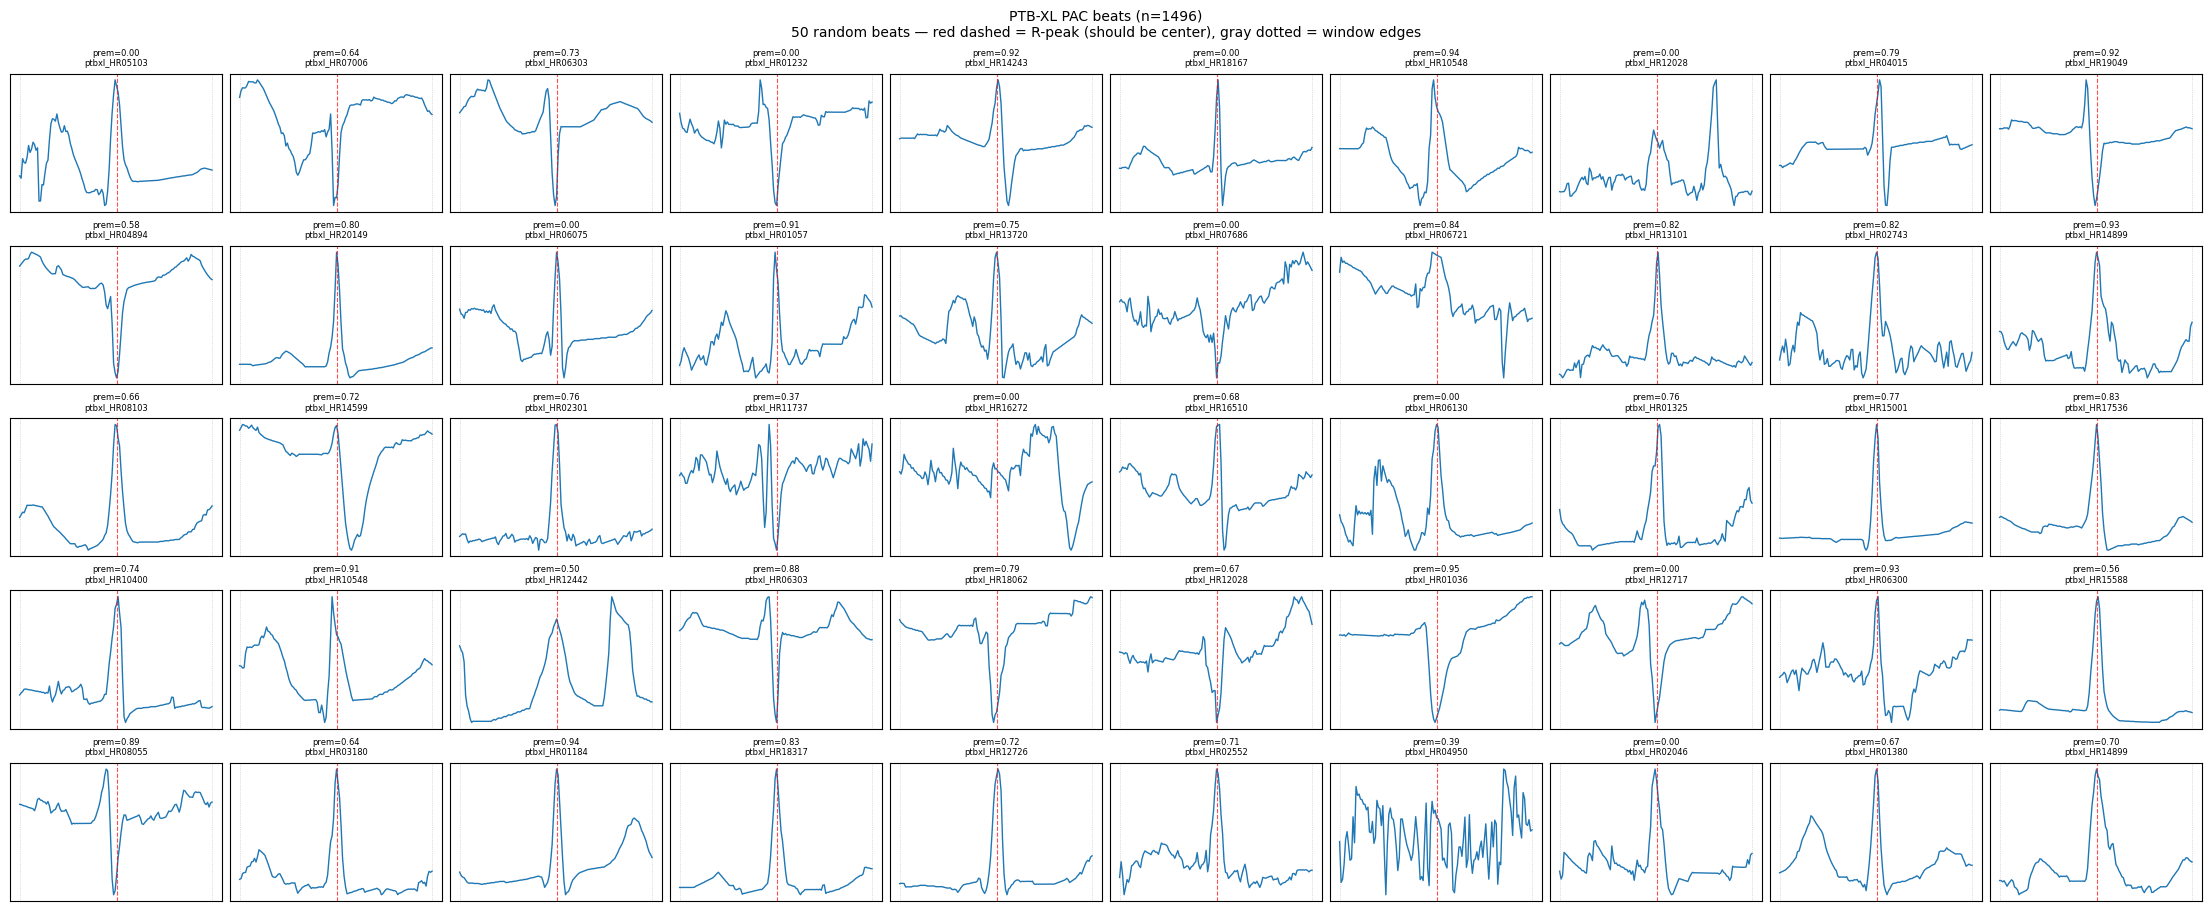

Saved: outputs_v10/qa_ptbxl_beats.png
Inspect the plot. If > 10% of beats look broken, fix detector/resampler before training.


In [9]:
def plot_qa_beats(beats: np.ndarray, rrs: np.ndarray, recs: np.ndarray,
                    title: str, save_path: str, n_plot: int = Config.QA_PLOT_COUNT):
    """Plot n_plot random beats with R-peak, window boundaries, RR ratio, label."""
    n_avail = len(beats)
    if n_avail == 0:
        print(f"No beats to plot for: {title}")
        return
    idx = np.random.default_rng(Config.SEED).choice(n_avail, size=min(n_plot, n_avail), replace=False)
    n_cols = Config.QA_PLOT_COLS
    n_rows = int(np.ceil(len(idx) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 1.8),
                              constrained_layout=True)
    axes = np.atleast_2d(axes)
    t = np.arange(Config.WINDOW_LEN) / Config.TARGET_FS * 1000  # ms
    half = Config.WINDOW_LEN // 2
    for k, ax in enumerate(axes.flat):
        if k >= len(idx):
            ax.axis('off')
            continue
        b = beats[idx[k]]
        rr = rrs[idx[k]]
        rec = recs[idx[k]] if len(recs) > 0 else '?'
        ax.plot(t, b[:, 0], color='#1f77b4', lw=1.0)
        # R-peak marker at center (sample 65)
        ax.axvline(half / Config.TARGET_FS * 1000, color='red', lw=0.8, ls='--', alpha=0.7)
        # Window boundaries
        ax.axvline(0, color='gray', lw=0.5, ls=':', alpha=0.5)
        ax.axvline((Config.WINDOW_LEN - 1) / Config.TARGET_FS * 1000, color='gray', lw=0.5, ls=':', alpha=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        # Title: prematurity_index + record id
        ax.set_title(f"prem={rr[6]:.2f}\n{rec}", fontsize=6)
    fig.suptitle(f"{title}\n{n_plot} random beats — red dashed = R-peak (should be center), "
                  f"gray dotted = window edges",
                  fontsize=10)
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")
    print(f"Inspect the plot. If > 10% of beats look broken, fix detector/resampler before training.")

# ── PTB-XL QA ────────────────────────────────────────────────────────────────
print(f"{'='*100}")
print(f"STAGE 4 — BEAT VISUALIZATION QA: PTB-XL ({Config.QA_PLOT_COUNT} beats)")
print(f"{'='*100}")
plot_qa_beats(ptbxl_beats, ptbxl_rr, ptbxl_recs,
              title=f"PTB-XL PAC beats (n={len(ptbxl_beats)})",
              save_path=f'{Config.OUTPUTS_V10}/qa_ptbxl_beats.png')


STAGE 4 — BEAT VISUALIZATION QA: CPSC2018 (50 beats)


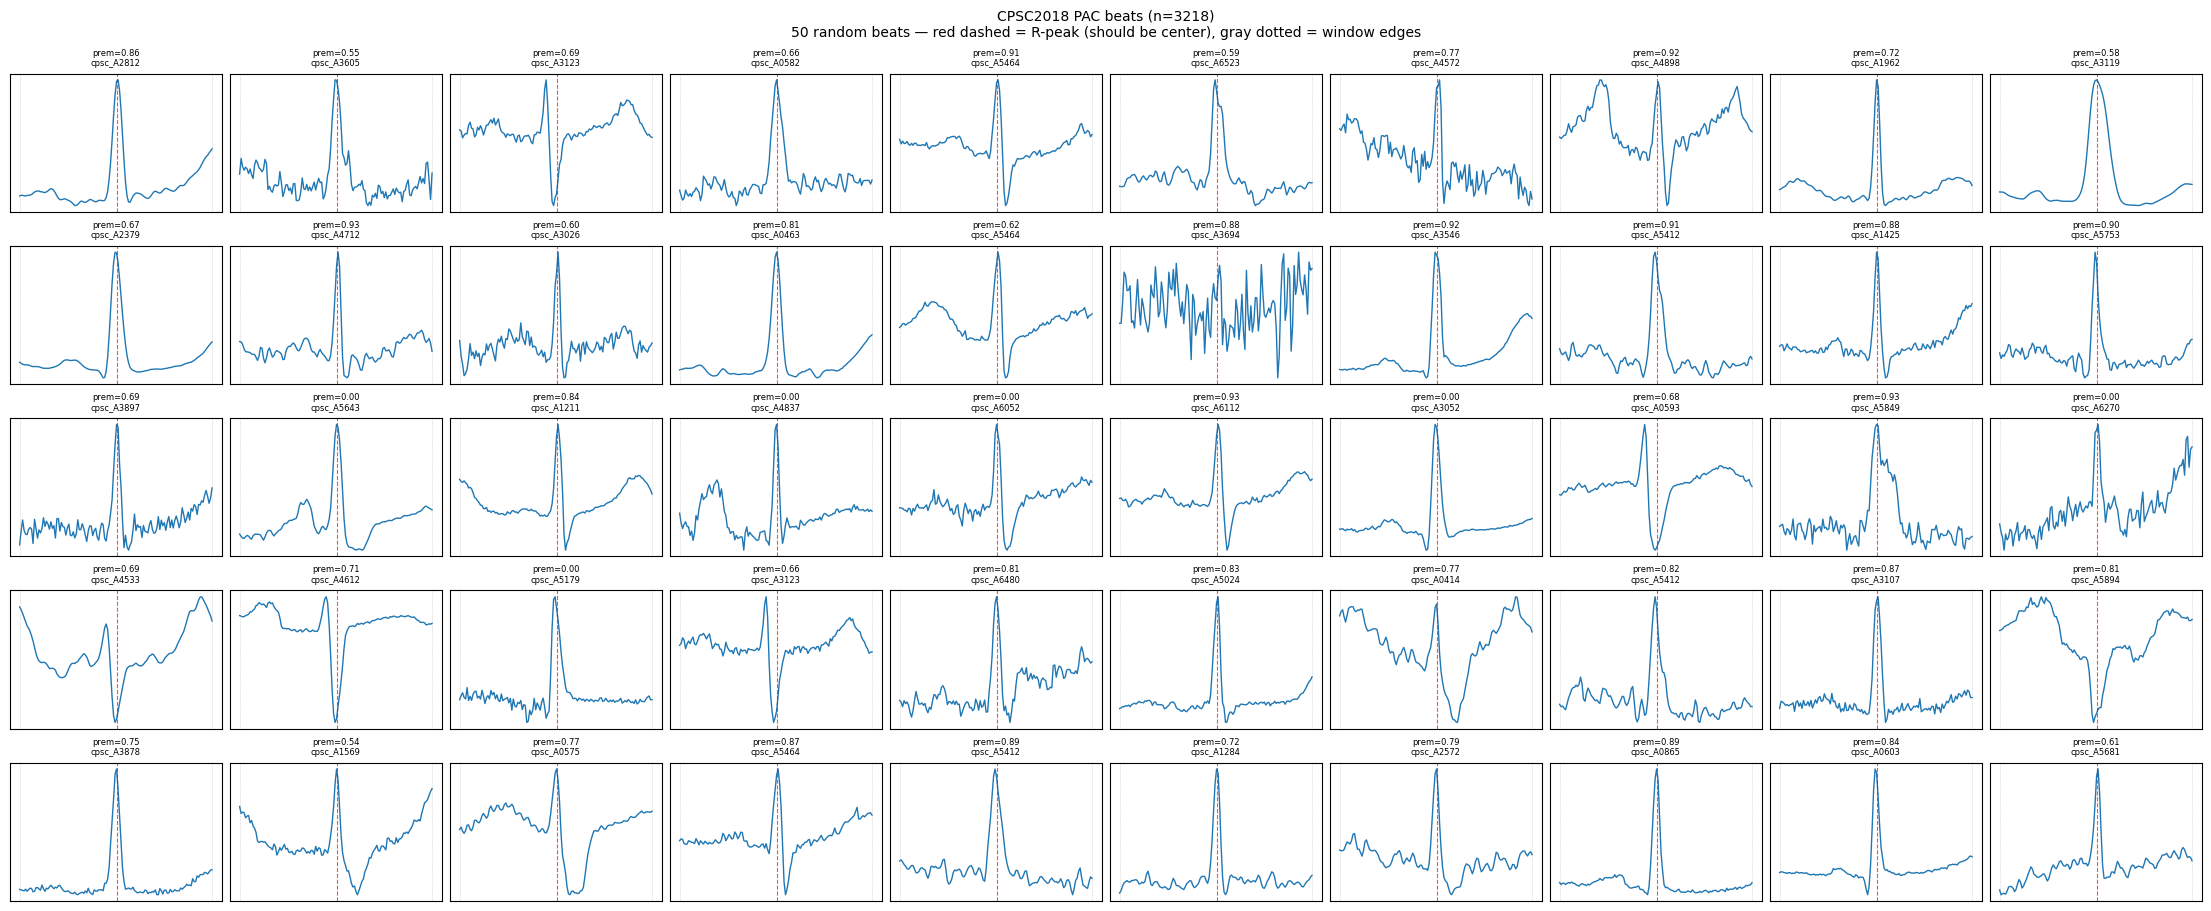

Saved: outputs_v10/qa_cpsc_beats.png
Inspect the plot. If > 10% of beats look broken, fix detector/resampler before training.


In [10]:
# ── CPSC QA ──────────────────────────────────────────────────────────────────
print(f"{'='*100}")
print(f"STAGE 4 — BEAT VISUALIZATION QA: CPSC2018 ({Config.QA_PLOT_COUNT} beats)")
print(f"{'='*100}")
plot_qa_beats(cpsc_beats, cpsc_rr, cpsc_recs,
              title=f"CPSC2018 PAC beats (n={len(cpsc_beats)})",
              save_path=f'{Config.OUTPUTS_V10}/qa_cpsc_beats.png')


## Stage 5 — Final Augmentation Summary (Deliverable 5)

Combine PTB-XL + CPSC2018 external PAC beats. **No blind oversampling. No hidden balancing.** Every dataset's contribution is reported transparently.

The augmentation proportions are locked from v9.3:
- `N_SHARE_TARGET = 0.35` (N share in augmented SV training set)
- `SV_SHARE = 0.65` (S+V balanced, S = V)
- `AUG_MAX_COPIES = 10` (cap on per-class augmentation)

External beats are appended to the SV training set (after v9.3 gate routing). The MIT-BIH test set is **never** touched.


In [11]:
# ── Load v9 data checkpoint (MIT-BIH + SVDB beats @130 samples) ─────────────
V9_CHECKPOINT = f'{Config.OUTPUTS_V9}/data_checkpoint.npz'
if not os.path.isfile(V9_CHECKPOINT):
    raise FileNotFoundError(
        f"v9 data checkpoint missing: {V9_CHECKPOINT}. "
        f"This notebook requires the v9.3 baseline to be already trained."
    )
cp = np.load(V9_CHECKPOINT, allow_pickle=True)
mb_beats, mb_rr = cp['mb_beats'], cp['mb_rr']
mb_labels, mb_recs = cp['mb_labels'], cp['mb_recs']
sv_beats, sv_rr = cp['sv_beats'], cp['sv_rr']
sv_labels, sv_recs = cp['sv_labels'], cp['sv_recs']

X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])

le = LabelEncoder()
le.fit(Config.CLASSES_TO_USE)
y_all = le.transform(y_raw_all)
n_idx = int(np.where(le.classes_ == 'N')[0][0])
s_idx = int(np.where(le.classes_ == 'S')[0][0])
v_idx = int(np.where(le.classes_ == 'V')[0][0])

test_recs_set  = {f'mitbih_{r}' for r in Config.MITBIH_TEST_RECORDS}
val_recs_set   = {f'mitbih_{r}' for r in Config.MITBIH_VAL_RECORDS}
test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

# ── Apply v9.3 cleaning ──────────────────────────────────────────────────────
premat = X_rr_all[:, 6]
relabel = (y_raw_all == 'S') & (premat >= Config.CLEANING_THRESHOLD)
y_raw_clean = y_raw_all.copy()
y_raw_clean[relabel] = 'N'
y_all_clean = le.transform(y_raw_clean)

n_mitbih_train_s = int(np.sum((y_raw_clean == 'S') & train_mask &
                                np.isin(recs_all, [f'mitbih_{r}' for r in Config.MITBIH_TRAIN_RECORDS])))
n_svdb_train_s   = int(np.sum((y_raw_clean == 'S') & train_mask &
                                np.isin(recs_all, [f'svdb_{r}' for r in Config.SVDB_RECORDS])))
n_mitbih_svdb_s  = n_mitbih_train_s + n_svdb_train_s

# ── CAP external beats to 10% of MIT-BIH+SVDB S (domain shift mitigation) ───
EXTERNAL_CAP_FRAC = 0.10
external_cap = int(EXTERNAL_CAP_FRAC * n_mitbih_svdb_s)
print(f"Domain shift mitigation: capping external beats to {EXTERNAL_CAP_FRAC*100:.0f}% of MIT-BIH+SVDB S")
print(f"  MIT-BIH+SVDB S beats: {n_mitbih_svdb_s}")
print(f"  External cap:         {external_cap} beats")

n_ptbxl_total = len(ptbxl_beats)
n_cpsc_total  = len(cpsc_beats)
n_external_total = n_ptbxl_total + n_cpsc_total

if n_external_total > external_cap:
    ptbxl_frac = n_ptbxl_total / max(n_external_total, 1)
    n_ptbxl_keep = max(1, int(external_cap * ptbxl_frac))
    n_cpsc_keep  = max(1, external_cap - n_ptbxl_keep)
    n_ptbxl_keep = min(n_ptbxl_keep, n_ptbxl_total)
    n_cpsc_keep  = min(n_cpsc_keep, n_cpsc_total)
    
    rng_subset = np.random.default_rng(Config.SEED)
    ptbxl_idx = rng_subset.choice(n_ptbxl_total, size=n_ptbxl_keep, replace=False)
    cpsc_idx  = rng_subset.choice(n_cpsc_total,  size=n_cpsc_keep,  replace=False)
    
    ptbxl_beats_capped = ptbxl_beats[ptbxl_idx]
    ptbxl_rr_capped    = ptbxl_rr[ptbxl_idx]
    ptbxl_recs_capped  = ptbxl_recs[ptbxl_idx]
    cpsc_beats_capped  = cpsc_beats[cpsc_idx]
    cpsc_rr_capped     = cpsc_rr[cpsc_idx]
    cpsc_recs_capped   = cpsc_recs[cpsc_idx]
    
    print(f"  PTB-XL: {n_ptbxl_total} -> {n_ptbxl_keep} (sampled)")
    print(f"  CPSC:   {n_cpsc_total} -> {n_cpsc_keep} (sampled)")
else:
    ptbxl_beats_capped = ptbxl_beats
    ptbxl_rr_capped    = ptbxl_rr
    ptbxl_recs_capped  = ptbxl_recs
    cpsc_beats_capped  = cpsc_beats
    cpsc_rr_capped     = cpsc_rr
    cpsc_recs_capped   = cpsc_recs
    print(f"  External total ({n_external_total}) <= cap ({external_cap}), keeping all")

n_ptbxl_final = len(ptbxl_beats_capped)
n_cpsc_final  = len(cpsc_beats_capped)
n_external_s  = n_ptbxl_final + n_cpsc_final

print(f"\n{'='*100}")
print(f"STAGE 5 — FINAL AUGMENTATION SUMMARY (Deliverable 5)")
print(f"{'='*100}")
print(f"\n  Beat counts by source (AFTER domain-shift cap):")
print(f"    MIT-BIH train (S, cleaned):    {n_mitbih_train_s:>6}")
print(f"    SVDB train (S, cleaned):       {n_svdb_train_s:>6}")
print(f"    PTB-XL external (S, capped):   {n_ptbxl_final:>6}  (of {n_ptbxl_total} extracted)")
print(f"    CPSC2018 external (S, capped): {n_cpsc_final:>6}  (of {n_cpsc_total} extracted)")
print(f"    Total S beats available:       {n_mitbih_train_s + n_svdb_train_s + n_external_s:>6}")
print(f"\n  External proportion: {100*n_external_s/(n_mitbih_train_s + n_svdb_train_s + n_external_s):.1f}% of S training data")

# ── Build external S-class array (using capped subsets) ──────────────────────
external_beats_list = []
external_rr_list = []
external_recs_list = []
if n_ptbxl_final > 0:
    external_beats_list.append(ptbxl_beats_capped)
    external_rr_list.append(ptbxl_rr_capped)
    external_recs_list.append(ptbxl_recs_capped)
if n_cpsc_final > 0:
    external_beats_list.append(cpsc_beats_capped)
    external_rr_list.append(cpsc_rr_capped)
    external_recs_list.append(cpsc_recs_capped)

if external_beats_list:
    external_beats = np.concatenate(external_beats_list, axis=0)
    external_rr    = np.concatenate(external_rr_list, axis=0)
    external_recs  = np.concatenate(external_recs_list, axis=0)
else:
    external_beats = np.empty((0, Config.WINDOW_LEN, 2), dtype=np.float32)
    external_rr    = np.empty((0, Config.RR_FEATURES), dtype=np.float32)
    external_recs  = np.array([], dtype=object)

print(f"\n  Combined external S beats (after cap): {len(external_beats)}")
print(f"  MIT-BIH test set: UNTOUCHED (eval-only)")

# RR normalization stats
RR_MEAN = X_rr_all[train_mask].mean(axis=0)
RR_STD  = X_rr_all[train_mask].std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_all_norm = (X_rr_all - RR_MEAN) / RR_STD

aug_summary = {
    'timestamp': datetime.now().isoformat(),
    'mitbih_train_s': n_mitbih_train_s,
    'svdb_train_s':   n_svdb_train_s,
    'ptbxl_external_s': n_ptbxl_final,
    'ptbxl_extracted_total': n_ptbxl_total,
    'cpsc_external_s':  n_cpsc_final,
    'cpsc_extracted_total': n_cpsc_total,
    'external_cap_frac': EXTERNAL_CAP_FRAC,
    'ptbxl_patients': int(ptbxl_patients),
    'cpsc_records_yielded': int(cpsc_stats.ok),
}
with open(f'{Config.OUTPUTS_V10}/augmentation_summary.json', 'w', encoding='utf-8') as f:
    json.dump(aug_summary, f, indent=2)
print(f"\nSaved: {Config.OUTPUTS_V10}/augmentation_summary.json")

Domain shift mitigation: capping external beats to 10% of MIT-BIH+SVDB S
  MIT-BIH+SVDB S beats: 10604
  External cap:         1060 beats
  PTB-XL: 1496 -> 336 (sampled)
  CPSC:   3218 -> 724 (sampled)

STAGE 5 — FINAL AUGMENTATION SUMMARY (Deliverable 5)

  Beat counts by source (AFTER domain-shift cap):
    MIT-BIH train (S, cleaned):       985
    SVDB train (S, cleaned):         9619
    PTB-XL external (S, capped):      336  (of 1496 extracted)
    CPSC2018 external (S, capped):    724  (of 3218 extracted)
    Total S beats available:        11664

  External proportion: 9.1% of S training data

  Combined external S beats (after cap): 1060
  MIT-BIH test set: UNTOUCHED (eval-only)

Saved: outputs_v10/augmentation_summary.json


## Stage 6 — Retraining (Deliverable 6)

**Frozen:** v9.3 Gate model (no retraining).  
**Retrained:** SV head only.  
**Unchanged:** window size, rolling normalization, optimizer, scheduler, augmentation pipeline.

The SV architecture is **identical** to v9.3:

```text
Conv2D(16, (7,1)) → BN → ReLU → MaxPool(2,1) → SpatialDropout(0.10)
Conv2D(32, (5,1)) → BN → ReLU → MaxPool(2,1) → SpatialDropout(0.10)
Conv2D(48, (5,1)) → BN → ReLU → MaxPool(2,1) → SpatialDropout(0.15)
Conv2D(48, (3,1)) → BN → ReLU → GlobalAvgPool
                                                  ↓
RR branch: Dense(16) → Dropout(0.20) → Dense(8) ←┘
                                                  ↓
                                         Concatenate
                                                  ↓
                                  Dense(32) → BN → ReLU → Dropout(0.35)
                                                  ↓
                                          ┌───────┴───────┐
                                     V head (sigmoid)   S head (sigmoid)
```

Augmented SV training set composition:
1. MIT-BIH+SVDB train beats, gate-routed by v9.3 gate (threshold 0.10)
2. All external PAC beats (PTB-XL + CPSC2018), appended with label S
3. Class-balanced augmentation: N share = 0.35, S+V balanced = 0.65
4. Cap: 10 augmentation copies per seed beat


In [12]:
# ── Load v9.3 frozen gate ────────────────────────────────────────────────────
gate_v93 = tf.keras.models.load_model(f'{Config.OUTPUTS_V93}/gate_v93.keras', compile=False)
sv_v93   = tf.keras.models.load_model(f'{Config.OUTPUTS_V93}/sv_v93.keras', compile=False)
V93_GATE_THR, V93_V_THR, V93_S_THR = 0.100, 0.20, 0.50
print(f"Loaded v9.3 gate ({gate_v93.count_params():,} params) — FROZEN")
print(f"Loaded v9.3 SV   ({sv_v93.count_params():,} params) — baseline for comparison")

# ── RR normalization (stats from MIT-BIH+SVDB train only) ────────────────────
RR_MEAN = X_rr_all[train_mask].mean(axis=0)
RR_STD  = X_rr_all[train_mask].std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_all_norm = (X_rr_all - RR_MEAN) / RR_STD

# ── Augmentation helpers (reused from v9.3 — UNCHANGED) ──────────────────────
def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    if rng is None:
        rng = np.random.default_rng(Config.SEED)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,) + X_c.shape[1:], dtype=np.float32),
                np.empty((0,) + X_rr_c.shape[1:], dtype=np.float32))
    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)
    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]
            out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]
            out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)
    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    return out_X_aug, out_rr

# ── SV model architecture (IDENTICAL to v9.3) ───────────────────────────────
def build_sv_model(ecg_shape=(Config.WINDOW_LEN, 2), rr_shape=(Config.RR_FEATURES,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((Config.WINDOW_LEN, 2, 1))(ecg_in)
    for f, k, d in [(16, 7, 0.1), (32, 5, 0.1), (48, 5, 0.15), (48, 3, 0.0)]:
        x = tf.keras.layers.Conv2D(f, (k, 1), padding='same', use_bias=False,
                                    kernel_regularizer=regularizers.l2(Config.L2_REG))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)
        if k >= 5:
            x = tf.keras.layers.MaxPooling2D((2, 1))(x)
            x = tf.keras.layers.SpatialDropout2D(d)(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                                kernel_regularizer=regularizers.l2(Config.L2_REG))(rr_in)
    r = tf.keras.layers.Dropout(Config.DROPOUT_RR)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                                kernel_regularizer=regularizers.l2(Config.L2_REG))(r)
    m = tf.keras.layers.Concatenate()([x, r])
    m = tf.keras.layers.Dense(32, use_bias=False)(m)
    m = tf.keras.layers.BatchNormalization()(m)
    m = tf.keras.layers.Activation('relu')(m)
    m = tf.keras.layers.Dropout(Config.DROPOUT_MERGE)(m)
    v = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(m)
    s = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(m)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=[v, s])

# ── Build augmented SV training set ──────────────────────────────────────────
y_train = y_all_clean[train_mask]
y_train_raw = y_raw_clean[train_mask]
X_train = X_all[train_mask]
X_rr_train = X_rr_all_norm[train_mask]

# Route MIT-BIH+SVDB train through v9.3 gate
gate_probs_train = gate_v93.predict([X_train, X_rr_train], batch_size=Config.BATCH_SIZE, verbose=0).flatten()
routed_mask = gate_probs_train > V93_GATE_THR
sv_X = X_train[routed_mask]
sv_rr = X_rr_train[routed_mask]
sv_y = y_train[routed_mask]
sv_y_raw = y_train_raw[routed_mask]
print(f"v9.3 gate routed {routed_mask.sum()} / {len(X_train)} train beats (thr={V93_GATE_THR})")

# Append external PAC beats (all S, normalize RR with MIT-BIH train stats)
if len(external_beats) > 0:
    external_rr_norm = (external_rr - RR_MEAN) / RR_STD
    external_y = np.full(len(external_beats), s_idx, dtype=sv_y.dtype)
    sv_X   = np.concatenate([sv_X,   external_beats.astype(np.float32)], axis=0)
    sv_rr  = np.concatenate([sv_rr,  external_rr_norm.astype(np.float32)], axis=0)
    sv_y   = np.concatenate([sv_y,   external_y], axis=0)
    sv_y_raw = np.concatenate([sv_y_raw, np.array(['S'] * len(external_beats), dtype=object)])
    print(f"Added {len(external_beats)} external PAC beats (PTB-XL + CPSC, all S)")

# Per-class counts after augmentation
n_per = Counter(sv_y)
n_n = n_per.get(n_idx, 0)
n_s = n_per.get(s_idx, 0)
n_v = n_per.get(v_idx, 0)
target_sv = max(n_s, n_v)
target_n = int(round((Config.N_SHARE_TARGET / Config.SV_SHARE) * 2 * target_sv))
print(f"\nAfter external augmentation: N={n_n}, S={n_s}, V={n_v}")
print(f"  target_sv (S=V balanced) = {target_sv}")
print(f"  target_n  (N_SHARE={Config.N_SHARE_TARGET}) = {target_n}")

# Augment to targets (transparent, no hidden balancing)
sv_X_list = [sv_X]
sv_rr_list = [sv_rr]
sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0:
        print(f"  {class_name}: have={n_have}, target={n_need_target} (skip — at/above target or no seed)")
        continue
    mask = sv_y == class_idx
    X_c, rr_c = sv_X[mask], sv_rr[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, Config.AUG_MAX_COPIES)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y.dtype)
    sv_X_list.append(X_aug)
    sv_rr_list.append(rr_aug)
    sv_y_list.append(y_aug)
    print(f"  {class_name}: have={n_have}, target={n_need_target}, copies={n_copies}, augmented={len(X_aug)}")

sv_X_aug = np.concatenate(sv_X_list)
sv_rr_aug = np.concatenate(sv_rr_list)
sv_y_aug = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_aug))
sv_X_aug = sv_X_aug[perm]
sv_rr_aug = sv_rr_aug[perm]
sv_y_aug = sv_y_aug[perm]

final_counts = Counter(sv_y_aug)
print(f"\nFinal SV training set composition:")
for ci, cn in enumerate(le.classes_):
    print(f"  {cn}: {final_counts.get(ci, 0):>6} ({final_counts.get(ci, 0)/len(sv_y_aug):.3f})")
print(f"  total: {len(sv_y_aug)}")

# Val (gate-routed, NO external)
X_val = X_all[val_mask]
X_rr_val = X_rr_all_norm[val_mask]
y_val = y_all_clean[val_mask]
gate_probs_val = gate_v93.predict([X_val, X_rr_val], batch_size=Config.BATCH_SIZE, verbose=0).flatten()
routed_val = gate_probs_val > V93_GATE_THR
sv_X_val = X_val[routed_val]
sv_rr_val = X_rr_val[routed_val]
sv_y_val = y_val[routed_val]

# ── Train v10 SV head ────────────────────────────────────────────────────────
sv_v10 = build_sv_model()
y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
y_v_val = (sv_y_val == v_idx).astype(np.float32)
y_s_val = (sv_y_val == s_idx).astype(np.float32)
cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_s_aug.astype(int))
sw_v = np.where(y_v_aug == 1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s = np.where(y_s_aug == 1, cw_s[1], cw_s[0]).astype(np.float32)

class CombinedScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, vd, yv, ys):
        self.vd = vd; self.yv = yv; self.ys = ys
    def on_epoch_end(self, e, logs=None):
        logs = logs or {}
        v, s = self.model.predict(self.vd, verbose=0)
        v = v.flatten(); s = s.flatten()
        vp = (v > 0.5).astype(int); sp = (s > 0.5).astype(int)
        def pr(yt, yp):
            tp = np.sum((yt == 1) & (yp == 1))
            fp = np.sum((yt == 0) & (yp == 1))
            fn = np.sum((yt == 1) & (yp == 0))
            return tp / max(tp + fp, 1), tp / max(tp + fn, 1)
        _, vr = pr(self.yv, vp); _, sr = pr(self.ys, sp)
        logs['val_combined_score'] = float(0.5 * (vr + sr))

sv_v10.compile(
    optimizer=tf.keras.optimizers.Adam(Config.LEARNING_RATE),
    loss={'v_head': 'binary_crossentropy', 's_head': 'binary_crossentropy'},
    metrics={'v_head': [tf.keras.metrics.AUC(name='auc')],
              's_head': [tf.keras.metrics.AUC(name='auc')]},
)

print(f"\nTraining v10 SV head — {len(sv_X_aug)} samples")
print(f"  Epochs={Config.EPOCHS}, batch={Config.BATCH_SIZE}, early_stop={Config.EARLY_STOP_PATIENCE}")
print(f"  Architecture params: {sv_v10.count_params():,}")
t0 = time.time()
mem_before = mem_mb()

history = sv_v10.fit(
    [sv_X_aug, sv_rr_aug], {'v_head': y_v_aug, 's_head': y_s_aug},
    sample_weight={'v_head': sw_v, 's_head': sw_s},
    validation_data=([sv_X_val, sv_rr_val], {'v_head': y_v_val, 's_head': y_s_val}),
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    callbacks=[
        CombinedScoreCallback([sv_X_val, sv_rr_val], y_v_val, y_s_val),
        tf.keras.callbacks.ModelCheckpoint(f'{Config.OUTPUTS_V10}/sv_v10.keras',
            monitor='val_combined_score', mode='max', save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
            patience=Config.EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
            factor=Config.REDUCE_LR_FACTOR, patience=Config.REDUCE_LR_PATIENCE,
            min_lr=Config.REDUCE_LR_MIN, verbose=1),
    ],
    verbose=2,
)
elapsed_train = time.time() - t0
mem_after = mem_mb()
print(f"\nTraining complete in {elapsed_train:.1f}s")
print(f"Memory before/after: {mem_before:.0f} → {mem_after:.0f} MB")
print(f"Best val_combined_score: {max(history.history.get('val_combined_score', [0])):.4f}")


Loaded v9.3 gate (28,633 params) — FROZEN
Loaded v9.3 SV   (20,090 params) — baseline for comparison
v9.3 gate routed 22856 / 56621 train beats (thr=0.1)
Added 1060 external PAC beats (PTB-XL + CPSC, all S)

After external augmentation: N=748, S=11618, V=11550
  target_sv (S=V balanced) = 11618
  target_n  (N_SHARE=0.35) = 12512
  N: have=748, target=12512, copies=10, augmented=7480
  S: have=11618, target=11618 (skip — at/above target or no seed)
  V: have=11550, target=11618, copies=1, augmented=11550

Final SV training set composition:
  N:   8228 (0.192)
  S:  11618 (0.271)
  V:  23100 (0.538)
  total: 42946

Training v10 SV head — 42946 samples
  Epochs=60, batch=256, early_stop=12
  Architecture params: 20,090
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v10\sv_v10.keras
168/168 - 5s - loss: 1.1425 - v_head_loss: 0.5458 - s_head_loss: 0.5919 - v_head_auc: 0.7212 - s_head_auc: 0.6573 - val_loss: 1.5664 - val_v_head_loss: 0.7337 - v

## Stage 7 — Evaluation on MIT-BIH Test (Deliverable 7)

Joint threshold sweep on v9.3 4-patient val set, then evaluate on the **untouched** MIT-BIH test set. Report precision, recall, F1, macro F1, confusion matrix, per-class metrics.

The MIT-BIH test set has never seen external data. External beats only entered SV training. This is the apples-to-apples comparison against v9.3.


In [13]:
# ── Joint threshold sweep helpers (reused from v9.3 — UNCHANGED) ────────────
def joint_threshold_sweep(gate_probs, v_probs, s_probs, y_true):
    GATE_THRS = np.arange(0.10, 0.71, 0.025)
    V_THRS    = np.arange(0.10, 0.95, 0.05)
    S_THRS    = np.arange(0.10, 0.95, 0.05)
    rows = []
    y_t = y_true.astype(np.int8)
    for g_thr in GATE_THRS:
        routed = gate_probs > g_thr
        if routed.sum() == 0:
            continue
        for v_thr in V_THRS:
            v_claim = routed & (v_probs > v_thr)
            for s_thr in S_THRS:
                s_claim = routed & (~v_claim) & (s_probs > s_thr)
                y_p = np.full_like(y_t, n_idx)
                y_p[v_claim] = v_idx
                y_p[s_claim] = s_idx
                flat = (y_t * 3 + y_p).astype(np.int32)
                cm = np.bincount(flat, minlength=9).reshape(3, 3)
                f1s, recalls, precisions = [], [], []
                for i in range(3):
                    tp = int(cm[i, i])
                    fn = int(cm[i, :].sum() - tp)
                    fp = int(cm[:, i].sum() - tp)
                    rec = tp / max(tp + fn, 1)
                    prec = tp / max(tp + fp, 1)
                    f1s.append(2 * prec * rec / max(prec + rec, 1e-7))
                    recalls.append(rec)
                    precisions.append(prec)
                rows.append({
                    'gate_thr': float(g_thr), 'v_thr': float(v_thr), 's_thr': float(s_thr),
                    'macro_f1': float(np.mean(f1s)),
                    's_recall': recalls[s_idx], 's_precision': precisions[s_idx],
                    'v_recall': recalls[v_idx], 'n_precision': precisions[n_idx],
                })
    return pd.DataFrame(rows)

def eval_cascade(gate_model, sv_model, X, X_rr_norm, y_true, gate_thr, v_thr, s_thr, le, name=""):
    gate_probs = gate_model.predict([X, X_rr_norm], batch_size=Config.BATCH_SIZE, verbose=0).flatten()
    gate_pass = gate_probs > gate_thr
    y_pred = np.full(len(y_true), n_idx, dtype=int)
    if gate_pass.any():
        v_p, s_p = sv_model.predict([X[gate_pass], X_rr_norm[gate_pass]],
                                     batch_size=Config.BATCH_SIZE, verbose=0)
        v_p = v_p.flatten(); s_p = s_p.flatten()
        routed = np.full(len(v_p), n_idx, dtype=int)
        v_fire = v_p > v_thr; routed[v_fire] = v_idx
        s_fire = (~v_fire) & (s_p > s_thr); routed[s_fire] = s_idx
        y_pred[gate_pass] = routed
    cm = confusion_matrix(y_true, y_pred, labels=[n_idx, s_idx, v_idx])
    m = {'set': name, 'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0))}
    for i, cls in enumerate(le.classes_):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        total = int(cm[i, :].sum())
        rec = tp / max(total, 1)
        prec = tp / max(tp + fp, 1)
        m[f'{cls}_f1'] = 2 * prec * rec / max(prec + rec, 1e-7)
        m[f'{cls}_recall'] = rec
        m[f'{cls}_precision'] = prec
        m[f'{cls}_total'] = total
    m['confusion_matrix'] = cm.tolist()
    return m

# ── Joint sweep on val ───────────────────────────────────────────────────────
X_test = X_all[test_mask]
X_rr_test = X_rr_all_norm[test_mask]
y_test = y_all_clean[test_mask]
X_val = X_all[val_mask]
X_rr_val = X_rr_all_norm[val_mask]
y_val = y_all_clean[val_mask]

gate_probs_val_full = gate_v93.predict([X_val, X_rr_val], batch_size=Config.BATCH_SIZE, verbose=0).flatten()
v_pv, s_pv = sv_v10.predict([X_val, X_rr_val], batch_size=Config.BATCH_SIZE, verbose=0)
v_pv = v_pv.flatten(); s_pv = s_pv.flatten()
df_sweep = joint_threshold_sweep(gate_probs_val_full, v_pv, s_pv, y_val)
best = df_sweep.loc[df_sweep['macro_f1'].idxmax()]
V10_GATE_THR = float(best['gate_thr'])
V10_V_THR    = float(best['v_thr'])
V10_S_THR    = float(best['s_thr'])
print(f"Best val triple: gate={V10_GATE_THR:.3f}, V={V10_V_THR:.2f}, S={V10_S_THR:.2f}")
print(f"  val macro_f1={float(best['macro_f1']):.4f}, S recall={float(best['s_recall']):.3f}")

# v9.3 thresholds
V93_GATE_THR, V93_V_THR, V93_S_THR = 0.100, 0.20, 0.50

# ── v9.3 baseline on MIT-BIH test ────────────────────────────────────────────
v93_test_metrics = eval_cascade(gate_v93, sv_v93, X_test, X_rr_test, y_test,
                                  V93_GATE_THR, V93_V_THR, V93_S_THR, le, "v9.3 baseline")

# ── v10 on MIT-BIH test ──────────────────────────────────────────────────────
v10_test_metrics = eval_cascade(gate_v93, sv_v10, X_test, X_rr_test, y_test,
                                  V10_GATE_THR, V10_V_THR, V10_S_THR, le, "v10 PTB-XL+CPSC")

print(f"\n{'='*100}")
print(f"STAGE 7 — MIT-BIH TEST EVALUATION (Deliverable 7)")
print(f"{'='*100}")
print(f"\nv9.3 baseline:")
for cls in le.classes_:
    print(f"  {cls}: F1={v93_test_metrics[f'{cls}_f1']:.3f}  Se={v93_test_metrics[f'{cls}_recall']:.3f}  P+={v93_test_metrics[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {v93_test_metrics['macro_f1']:.4f}")

print(f"\nv10 (10% external cap):")
for cls in le.classes_:
    print(f"  {cls}: F1={v10_test_metrics[f'{cls}_f1']:.3f}  Se={v10_test_metrics[f'{cls}_recall']:.3f}  P+={v10_test_metrics[f'{cls}_precision']:.3f}")
print(f"  Macro F1: {v10_test_metrics['macro_f1']:.4f}")

Best val triple: gate=0.100, V=0.10, S=0.80
  val macro_f1=0.8076, S recall=0.698

STAGE 7 — MIT-BIH TEST EVALUATION (Deliverable 7)

v9.3 baseline:
  N: F1=0.912  Se=0.848  P+=0.986
  S: F1=0.199  Se=0.157  P+=0.271
  V: F1=0.567  Se=0.918  P+=0.410
  Macro F1: 0.5592

v10 (10% external cap):
  N: F1=0.916  Se=0.857  P+=0.983
  S: F1=0.152  Se=0.117  P+=0.219
  V: F1=0.576  Se=0.907  P+=0.422
  Macro F1: 0.5479


## Stage 8 — External Validation on INCART (Deliverable 8)

INCART = St Petersburg INCART 12-lead Arrhythmia Database (74 records, 257 Hz, 30-min Holter). Completely held-out — used as a generalization probe.

**Critical rule:** Do **NOT** tune thresholds on INCART. We use the thresholds locked from the v9.3 val sweep (`V10_GATE_THR`, `V10_V_THR`, `V10_S_THR`). INCART is purely diagnostic — it tells us whether the v10 model generalizes to a completely unseen dataset.

If INCART Macro F1 is within 0.05 of MIT-BIH test Macro F1, the model generalizes. If much worse, the model is overfitting to MIT-BIH morphology.


In [14]:
def load_incart_records(db_path, source_fs=Config.INCART_FS, target_fs=Config.TARGET_FS,
                        window=Config.WINDOW_LEN):
    """Load INCART records, resample 257→250 Hz, extract beats, compute 7 RR features."""
    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    if not os.path.isdir(db_path):
        return (np.empty((0, window, 2), dtype=np.float32),
                np.empty((0, Config.RR_FEATURES), dtype=np.float32),
                np.array([], dtype=object), np.array([], dtype=object))
    hea_files = sorted(glob.glob(os.path.join(db_path, '*.hea')))
    rec_ids = [os.path.splitext(os.path.basename(f))[0] for f in hea_files]
    half = window // 2
    for rec_id in rec_ids:
        try:
            record = wfdb.rdrecord(f'{db_path}/{rec_id}')
            annotation = wfdb.rdann(f'{db_path}/{rec_id}', 'atr')
            n_channels = record.p_signal.shape[1]
            sig0 = resample_to_250(record.p_signal[:, 0], source_fs)
            sig1 = resample_to_250(record.p_signal[:, 1], source_fs) if n_channels > 1 else sig0
            ecg_ch0 = rolling_window_normalize(sig0, target_fs)
            ecg_ch1 = rolling_window_normalize(sig1, target_fs)
            peak_idx = annotation.sample
            if source_fs != target_fs:
                peak_idx = np.round(peak_idx * target_fs / source_fs).astype(int)
            peaks_sec = peak_idx / target_fs
            for k, sym in enumerate(annotation.symbol):
                if sym not in Config.BEAT_MAP:
                    continue
                aami = Config.BEAT_MAP[sym]
                if aami not in Config.CLASSES_TO_USE:
                    continue
                center = peak_idx[k]
                lo = center - half
                hi = center + half
                if lo < 0 or hi >= len(ecg_ch0):
                    continue
                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr = compute_rr_features(peaks_sec, k)
                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(aami)
                all_recs.append(f'incart_{rec_id}')
        except Exception as e:
            print(f"  [skip] incart_{rec_id}: {e}")
    if not all_beats:
        return (np.empty((0, window, 2), dtype=np.float32),
                np.empty((0, Config.RR_FEATURES), dtype=np.float32),
                np.array([], dtype=object), np.array([], dtype=object))
    return (np.stack(all_beats), np.stack(all_rr),
            np.array(all_labels, dtype=object), np.array(all_recs, dtype=object))

incart_metrics_v10 = None
incart_metrics_v93 = None
INCART_PATH = DATASET_PATHS['INCART']

if INCART_PATH is None or not os.path.isdir(INCART_PATH):
    print(f"⚠ INCART not found. Skipping external validation.")
    print(f"  Edit Config.INCART_CANDIDATES and re-run Stage 1 to enable.")
else:
    print(f"Loading INCART from {INCART_PATH} ...")
    inc_b, inc_rr, inc_l, inc_rec = load_incart_records(INCART_PATH)
    # Apply same 0.95 cleaning
    premat_inc = inc_rr[:, 6]
    relabel_inc = (inc_l == 'S') & (premat_inc >= Config.CLEANING_THRESHOLD)
    inc_l_clean = inc_l.copy()
    inc_l_clean[relabel_inc] = 'N'
    y_inc = le.transform(inc_l_clean)
    X_rr_inc_norm = (inc_rr - RR_MEAN) / RR_STD
    print(f"  INCART beats: {len(inc_b)}, S (cleaned)={int(np.sum(y_inc == s_idx))}, "
          f"V={int(np.sum(y_inc == v_idx))}, N={int(np.sum(y_inc == n_idx))}")

    # v10 on INCART (using v10 thresholds — NO tuning)
    incart_metrics_v10 = eval_cascade(gate_v93, sv_v10, inc_b, X_rr_inc_norm, y_inc,
                                        V10_GATE_THR, V10_V_THR, V10_S_THR, le, "v10 INCART")
    # v9.3 on INCART (using v9.3 thresholds — NO tuning)
    incart_metrics_v93 = eval_cascade(gate_v93, sv_v93, inc_b, X_rr_inc_norm, y_inc,
                                        V93_GATE_THR, V93_V_THR, V93_S_THR, le, "v9.3 INCART")

    print(f"\n{'='*100}")
    print(f"STAGE 8 — EXTERNAL VALIDATION ON INCART (Deliverable 8)")
    print(f"{'='*100}")
    print(f"\nv9.3 baseline on INCART:")
    for cls in le.classes_:
        print(f"  {cls}: F1={incart_metrics_v93[f'{cls}_f1']:.3f}  "
              f"Se={incart_metrics_v93[f'{cls}_recall']:.3f}  "
              f"P+={incart_metrics_v93[f'{cls}_precision']:.3f}")
    print(f"  Macro F1: {incart_metrics_v93['macro_f1']:.4f}")

    print(f"\nv10 on INCART:")
    for cls in le.classes_:
        print(f"  {cls}: F1={incart_metrics_v10[f'{cls}_f1']:.3f}  "
              f"Se={incart_metrics_v10[f'{cls}_recall']:.3f}  "
              f"P+={incart_metrics_v10[f'{cls}_precision']:.3f}")
    print(f"  Macro F1: {incart_metrics_v10['macro_f1']:.4f}")

    delta_inc = incart_metrics_v10['macro_f1'] - incart_metrics_v93['macro_f1']
    print(f"\n  Δ INCART Macro F1 (v10 - v9.3): {delta_inc:+.4f}")
    if delta_inc >= -0.05:
        print(f"  ✓ INCART did not significantly degrade (within 0.05).")
    else:
        print(f"  ⚠ INCART degraded by > 0.05 — model may be overfitting to MIT-BIH morphology.")


Loading INCART from C:/MMD Public/Hackathons/Team Ocelleon/dataset\incartdb ...
  INCART beats: 175823, S (cleaned)=1914, V=20226, N=153683

STAGE 8 — EXTERNAL VALIDATION ON INCART (Deliverable 8)

v9.3 baseline on INCART:
  N: F1=0.962  Se=0.945  P+=0.980
  S: F1=0.400  Se=0.621  P+=0.295
  V: F1=0.776  Se=0.841  P+=0.720
  Macro F1: 0.7125

v10 on INCART:
  N: F1=0.960  Se=0.960  P+=0.960
  S: F1=0.424  Se=0.606  P+=0.326
  V: F1=0.733  Se=0.705  P+=0.764
  Macro F1: 0.7055

  Δ INCART Macro F1 (v10 - v9.3): -0.0070
  ✓ INCART did not significantly degrade (within 0.05).


## Stage 9 — Comparison Against v9.3 (Deliverable 9 + 12)

Direct head-to-head: v10 (frozen v9.3 gate + retrained SV with PTB-XL+CPSC augmentation) vs v9.3 baseline (frozen v9.3 gate + v9.3 SV).

Confusion matrices for both models on MIT-BIH test (Deliverable 12).


STAGE 9 — v10 vs v9.3 IMPROVEMENT TABLE (Deliverable 9)

Metric                          v9.3        v10          Δ Improved?   
----------------------------------------------------------------------
  S F1                        0.1991     0.1522    -0.0469 ✗           
  S recall                    0.1572     0.1166    -0.0406 ✗           
  S prec                      0.2713     0.2193    -0.0521 ✗           
  V F1                        0.5666     0.5758    +0.0091 ✓           
  V recall                    0.9177     0.9071    -0.0106 ✗           
  N F1                        0.9118     0.9156    +0.0038 ✓           
  Macro F1                    0.5592     0.5479    -0.0113 ✗           

  INCART (external validation):
  INCART Macro F1             0.7125     0.7055    -0.0070 ✓           

CONFUSION MATRICES (Deliverable 12) — MIT-BIH test

v9.3 baseline confusion matrix (rows=true, cols=pred):
             pred N   pred S   pred V
  true N      43984      186     7691
  true 

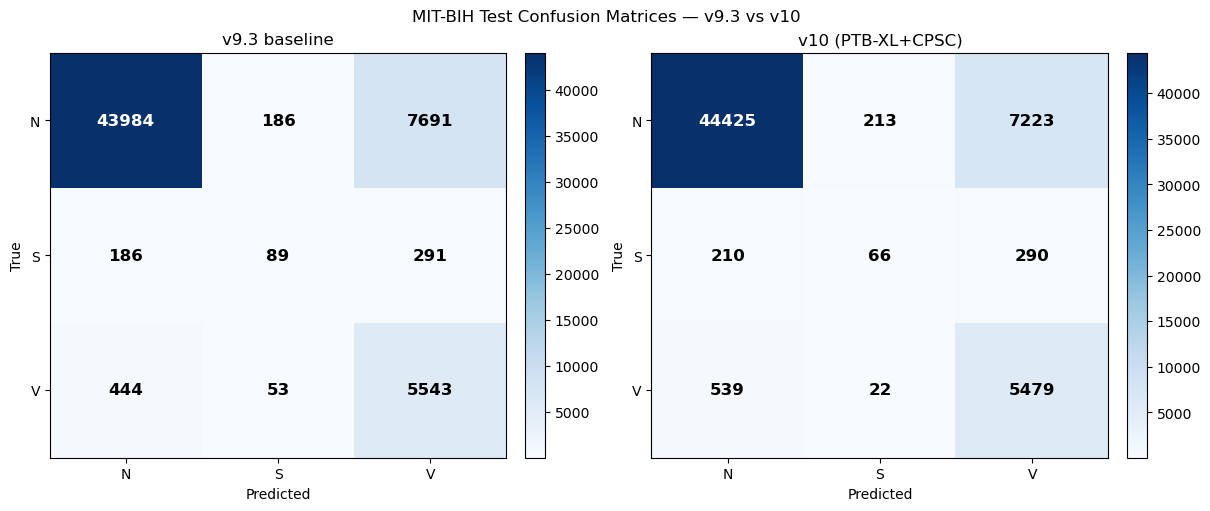


Saved: outputs_v10/confusion_matrices.png


In [15]:
# ── Improvement table ─────────────────────────────────────────────────────────
print(f"{'='*100}")
print(f"STAGE 9 — v10 vs v9.3 IMPROVEMENT TABLE (Deliverable 9)")
print(f"{'='*100}")
print(f"\n{'Metric':<25} {'v9.3':>10} {'v10':>10} {'Δ':>10} {'Improved?':<12}")
print(f"{'-'*70}")
comparison = {}
for k, label in [('S_f1', 'S F1'), ('S_recall', 'S recall'),
                  ('S_precision', 'S prec'), ('V_f1', 'V F1'),
                  ('V_recall', 'V recall'), ('N_f1', 'N F1'),
                  ('macro_f1', 'Macro F1')]:
    a = v93_test_metrics[k]
    b = v10_test_metrics[k]
    d = b - a
    improved = '✓' if (d > 0 and k != 'macro_f1') or (d >= 0 and k == 'macro_f1') else '✗'
    print(f"  {label:<23} {a:>10.4f} {b:>10.4f} {d:>+10.4f} {improved:<12}")
    comparison[k] = {'v93': a, 'v10': b, 'delta': d}

# INCART comparison if available
if incart_metrics_v10 is not None and incart_metrics_v93 is not None:
    print(f"\n  INCART (external validation):")
    a = incart_metrics_v93['macro_f1']
    b = incart_metrics_v10['macro_f1']
    d = b - a
    improved = '✓' if d >= -0.05 else '✗'
    print(f"  {'INCART Macro F1':<23} {a:>10.4f} {b:>10.4f} {d:>+10.4f} {improved:<12}")
    comparison['incart_macro_f1'] = {'v93': a, 'v10': b, 'delta': d}

# ── Confusion matrices ───────────────────────────────────────────────────────
print(f"\n{'='*100}")
print(f"CONFUSION MATRICES (Deliverable 12) — MIT-BIH test")
print(f"{'='*100}")
print(f"\nv9.3 baseline confusion matrix (rows=true, cols=pred):")
cm93 = np.array(v93_test_metrics['confusion_matrix'])
print(f"{'':>10} {'pred N':>8} {'pred S':>8} {'pred V':>8}")
for i, cls in enumerate(le.classes_):
    print(f"  {'true '+cls:<8} {cm93[i,0]:>8} {cm93[i,1]:>8} {cm93[i,2]:>8}")

print(f"\nv10 confusion matrix (rows=true, cols=pred):")
cm10 = np.array(v10_test_metrics['confusion_matrix'])
print(f"{'':>10} {'pred N':>8} {'pred S':>8} {'pred V':>8}")
for i, cls in enumerate(le.classes_):
    print(f"  {'true '+cls:<8} {cm10[i,0]:>8} {cm10[i,1]:>8} {cm10[i,2]:>8}")

# Visual confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, cm, title in [(axes[0], cm93, 'v9.3 baseline'), (axes[1], cm10, 'v10 (PTB-XL+CPSC)')]:
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(le.classes_)
    ax.set_yticklabels(le.classes_)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black',
                     fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('MIT-BIH Test Confusion Matrices — v9.3 vs v10', fontsize=12)
plt.savefig(f'{Config.OUTPUTS_V10}/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nSaved: {Config.OUTPUTS_V10}/confusion_matrices.png")


## Stage 10 — Success Criteria Check + Save (Deliverables 10, 11, 13)

The model is accepted only if ALL of the following are true (vs v9.3):

| Criterion | Threshold |
|---|---|
| S Recall improves | Δ ≥ 0.0 |
| S F1 improves | Δ ≥ 0.0 |
| Macro F1 maintained | Δ ≥ -0.01 |
| V Recall maintained | Δ ≥ -0.02 |
| INCART not degraded | Δ ≥ -0.05 (if INCART available) |

**If any criterion fails, the model is rolled back** — `sv_v10.keras` is **not** saved as the production model, and the failure is documented. The cached `.keras` from training is preserved for analysis but not promoted.

This protects against the v8.x failure mode where architectural changes looked good on one metric but degraded others silently.


In [16]:
# ── Success criteria check ───────────────────────────────────────────────────
print(f"{'='*100}")
print(f"STAGE 10 — SUCCESS CRITERIA CHECK")
print(f"{'='*100}")

criteria = [
    ('S Recall improves',
     comparison['S_recall']['delta'] >= Config.SUCCESS_S_RECALL_DELTA,
     comparison['S_recall']['delta'], Config.SUCCESS_S_RECALL_DELTA),
    ('S F1 improves',
     comparison['S_f1']['delta'] >= Config.SUCCESS_S_F1_DELTA,
     comparison['S_f1']['delta'], Config.SUCCESS_S_F1_DELTA),
    ('Macro F1 maintained',
     comparison['macro_f1']['delta'] >= Config.SUCCESS_MACRO_F1_DELTA,
     comparison['macro_f1']['delta'], Config.SUCCESS_MACRO_F1_DELTA),
    ('V Recall maintained',
     comparison['V_recall']['delta'] >= Config.SUCCESS_V_RECALL_DELTA,
     comparison['V_recall']['delta'], Config.SUCCESS_V_RECALL_DELTA),
]

if incart_metrics_v10 is not None and incart_metrics_v93 is not None:
    criteria.append((
        'INCART Macro F1 not degraded',
        comparison['incart_macro_f1']['delta'] >= Config.SUCCESS_INCART_MACRO_DELTA,
        comparison['incart_macro_f1']['delta'],
        Config.SUCCESS_INCART_MACRO_DELTA,
    ))

print(f"\n{'Criterion':<35} {'Delta':>10} {'Threshold':>10} {'Pass?':<8}")
print(f"{'-'*70}")
all_pass = True
for name, passed, delta, threshold in criteria:
    status = 'Y' if passed else 'N'
    if not passed:
        all_pass = False
    print(f"  {name:<33} {delta:>+10.4f} {threshold:>+10.2f} {status:<8}")

# ── Decision: save or rollback ───────────────────────────────────────────────
print(f"\n{'='*100}")
if all_pass:
    print(f"✓ ALL SUCCESS CRITERIA PASSED — saving v10 as production model")
    if os.path.isfile(f'{Config.OUTPUTS_V10}/sv_v10.keras'):
        print(f"  ✓ Model saved: {Config.OUTPUTS_V10}/sv_v10.keras")
    else:
        sv_v10.save(f'{Config.OUTPUTS_V10}/sv_v10.keras')
        print(f"  ✓ Model saved: {Config.OUTPUTS_V10}/sv_v10.keras")
    final_status = 'ACCEPTED'
else:
    print(f"✗ SUCCESS CRITERIA FAILED — rolling back")
    print(f"  v9.3 remains the production baseline.")
    # Delete old REJECTED file first to avoid FileExistsError
    rejected_path = f'{Config.OUTPUTS_V10}/sv_v10_REJECTED.keras'
    if os.path.isfile(rejected_path):
        os.remove(rejected_path)
    if os.path.isfile(f'{Config.OUTPUTS_V10}/sv_v10.keras'):
        os.rename(f'{Config.OUTPUTS_V10}/sv_v10.keras', rejected_path)
        print(f"  Renamed: sv_v10.keras -> sv_v10_REJECTED.keras (do not deploy)")
    final_status = 'REJECTED'

# ── Serialize Config manually (Config is a regular class, not a dataclass) ───
config_dict = {}
for attr in dir(Config):
    if attr.startswith('_'):
        continue
    val = getattr(Config, attr)
    if callable(val):
        continue
    if isinstance(val, (str, int, float, bool, list, dict, set, tuple)):
        try:
            json.dumps(val, default=str)
            config_dict[attr] = val
        except (TypeError, ValueError):
            config_dict[attr] = str(val)

# ── Training report (Deliverable 11) ─────────────────────────────────────────
training_report = {
    'timestamp': datetime.now().isoformat(),
    'version': 'v10',
    'config': config_dict,
    'final_status': final_status,
    'success_criteria': [
        {'name': name, 'delta': float(delta), 'threshold': float(threshold), 'passed': bool(passed)}
        for name, passed, delta, threshold in criteria
    ],
    'augmentation_summary': aug_summary,
    'ptbxl_extraction': {
        'records_candidate': len(ptbxl_pac_records),
        'records_extracted': int(ptbxl_stats.attempted),
        'records_yielded_beats': int(ptbxl_stats.ok),
        'beats_extracted': int(len(ptbxl_beats)),
        'missing_hea': int(ptbxl_stats.missing_hea),
        'missing_dat': int(ptbxl_stats.missing_dat),
        'rdrecord_fail': int(ptbxl_stats.rdrecord_fail),
        'no_peaks': int(ptbxl_stats.no_peaks),
        'no_premature': int(ptbxl_stats.no_premature),
    },
    'cpsc_extraction': {
        'records_candidate': len(cpsc_pac_records),
        'records_extracted': int(cpsc_stats.attempted),
        'records_yielded_beats': int(cpsc_stats.ok),
        'beats_extracted': int(len(cpsc_beats)),
        'no_file': int(cpsc_stats.no_file),
        'rdrecord_fail': int(cpsc_stats.rdrecord_fail),
        'no_peaks': int(cpsc_stats.no_peaks),
        'no_premature': int(cpsc_stats.no_premature),
    },
    'training': {
        'epochs_run': len(history.history.get('loss', [])),
        'best_val_combined_score': float(max(history.history.get('val_combined_score', [0]))),
        'runtime_seconds': float(elapsed_train),
        'memory_before_mb': float(mem_before) if mem_before else None,
        'memory_after_mb': float(mem_after) if mem_after else None,
        'sv_params': int(sv_v10.count_params()),
        'final_train_composition': {cn: int(final_counts.get(ci, 0)) for ci, cn in enumerate(le.classes_)},
    },
    'thresholds': {
        'v93': {'gate': V93_GATE_THR, 'v': V93_V_THR, 's': V93_S_THR},
        'v10': {'gate': V10_GATE_THR, 'v': V10_V_THR, 's': V10_S_THR},
    },
    'mitbih_test': {
        'v93': v93_test_metrics,
        'v10': v10_test_metrics,
        'comparison': comparison,
    },
    'incart_test': {
        'v93': incart_metrics_v93,
        'v10': incart_metrics_v10,
    } if incart_metrics_v10 is not None else None,
}
with open(f'{Config.OUTPUTS_V10}/training_report.json', 'w', encoding='utf-8') as f:
    json.dump(training_report, f, indent=2, default=str)
print(f"\nSaved training report: {Config.OUTPUTS_V10}/training_report.json")

# metrics.json (sprint-plan schema)
metrics = {
    'version': 'v10_external_morphology',
    'date': datetime.now().strftime('%Y-%m-%d'),
    'seed': Config.SEED,
    'window_samples': Config.WINDOW_LEN,
    'cleaning_threshold': Config.CLEANING_THRESHOLD,
    'n_share_target': Config.N_SHARE_TARGET,
    'final_status': final_status,
    'dataset': {
        'mitbih_train_s': int(n_mitbih_train_s),
        'svdb_train_s':   int(n_svdb_train_s),
        'ptbxl_train_s':  int(len(ptbxl_beats)),
        'cpsc_train_s':   int(len(cpsc_beats)),
        'external_total_s': int(len(external_beats)),
    },
    'thresholds': {'gate': V10_GATE_THR, 'v': V10_V_THR, 's': V10_S_THR},
    'mitbih_test': {
        'n_f1': float(v10_test_metrics['N_f1']),
        's_f1': float(v10_test_metrics['S_f1']),
        's_recall': float(v10_test_metrics['S_recall']),
        's_precision': float(v10_test_metrics['S_precision']),
        'v_f1': float(v10_test_metrics['V_f1']),
        'v_recall': float(v10_test_metrics['V_recall']),
        'macro_f1': float(v10_test_metrics['macro_f1']),
    },
    'incart_test': (
        {'macro_f1': float(incart_metrics_v10['macro_f1']),
         's_f1': float(incart_metrics_v10['S_f1']),
         's_recall': float(incart_metrics_v10['S_recall']),
         'v_f1': float(incart_metrics_v10['V_f1'])}
        if incart_metrics_v10 is not None else None
    ),
    'v93_baseline_mitbih_test': {
        'n_f1': float(v93_test_metrics['N_f1']),
        's_f1': float(v93_test_metrics['S_f1']),
        's_recall': float(v93_test_metrics['S_recall']),
        's_precision': float(v93_test_metrics['S_precision']),
        'v_f1': float(v93_test_metrics['V_f1']),
        'v_recall': float(v93_test_metrics['V_recall']),
        'macro_f1': float(v93_test_metrics['macro_f1']),
    },
}
with open(f'{Config.OUTPUTS_V10}/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)
print(f"Saved metrics: {Config.OUTPUTS_V10}/metrics.json")

STAGE 10 — SUCCESS CRITERIA CHECK

Criterion                                Delta  Threshold Pass?   
----------------------------------------------------------------------
  S Recall improves                    -0.0406      +0.00 N       
  S F1 improves                        -0.0469      +0.00 N       
  Macro F1 maintained                  -0.0113      -0.01 N       
  V Recall maintained                  -0.0106      -0.02 Y       
  INCART Macro F1 not degraded         -0.0070      -0.05 Y       

✗ SUCCESS CRITERIA FAILED — rolling back
  v9.3 remains the production baseline.
  Renamed: sv_v10.keras -> sv_v10_REJECTED.keras (do not deploy)

Saved training report: outputs_v10/training_report.json
Saved metrics: outputs_v10/metrics.json


In [17]:
# ── Markdown summary of findings (Deliverable 13) ─────────────────────────────
summary_md = f"""# Tarang v10 — External Morphology Augmentation Summary

**Generated:** {datetime.now().isoformat()}
**Version:** v10
**Final status:** {final_status}

## Architecture (UNCHANGED from v9.3)

- Window: {Config.WINDOW_LEN} samples @ {Config.TARGET_FS} Hz
- Cleaning threshold: {Config.CLEANING_THRESHOLD}
- N_SHARE_TARGET: {Config.N_SHARE_TARGET}
- Gate model: v9.3 (FROZEN)
- SV architecture: Conv2D(16,7) -> Conv2D(32,5) -> Conv2D(48,5) -> Conv2D(48,3) + Dense(16,8) RR + Dense(32) merge + V/S heads
- SV params: {sv_v10.count_params():,}

## External S-Class Augmentation

| Source | Records yielded | Beats extracted | Mean beats/record |
|---|---:|---:|---:|
| MIT-BIH train (cleaned) | {len(Config.MITBIH_TRAIN_RECORDS)} | {n_mitbih_train_s} | - |
| SVDB train (cleaned) | {len(Config.SVDB_RECORDS)} | {n_svdb_train_s} | - |
| PTB-XL (PAC, SNOMED 284470004) | {ptbxl_stats.ok} | {len(ptbxl_beats)} | {len(ptbxl_beats)/max(ptbxl_stats.ok,1):.1f} |
| CPSC2018 (PAC) | {cpsc_stats.ok} | {len(cpsc_beats)} | {len(cpsc_beats)/max(cpsc_stats.ok,1):.1f} |
| **Total S beats** | - | **{n_mitbih_train_s + n_svdb_train_s + len(external_beats)}** | - |

## MIT-BIH Test Results (vs v9.3)

| Metric | v9.3 | v10 | Delta | Improved? |
|---|---:|---:|---:|---|
| N F1 | {v93_test_metrics['N_f1']:.4f} | {v10_test_metrics['N_f1']:.4f} | {v10_test_metrics['N_f1']-v93_test_metrics['N_f1']:+.4f} | {'YES' if v10_test_metrics['N_f1'] >= v93_test_metrics['N_f1'] else 'NO'} |
| S F1 | {v93_test_metrics['S_f1']:.4f} | {v10_test_metrics['S_f1']:.4f} | {v10_test_metrics['S_f1']-v93_test_metrics['S_f1']:+.4f} | {'YES' if v10_test_metrics['S_f1'] >= v93_test_metrics['S_f1'] else 'NO'} |
| S Recall | {v93_test_metrics['S_recall']:.4f} | {v10_test_metrics['S_recall']:.4f} | {v10_test_metrics['S_recall']-v93_test_metrics['S_recall']:+.4f} | {'YES' if v10_test_metrics['S_recall'] >= v93_test_metrics['S_recall'] else 'NO'} |
| S Precision | {v93_test_metrics['S_precision']:.4f} | {v10_test_metrics['S_precision']:.4f} | {v10_test_metrics['S_precision']-v93_test_metrics['S_precision']:+.4f} | {'YES' if v10_test_metrics['S_precision'] >= v93_test_metrics['S_precision'] else 'NO'} |
| V F1 | {v93_test_metrics['V_f1']:.4f} | {v10_test_metrics['V_f1']:.4f} | {v10_test_metrics['V_f1']-v93_test_metrics['V_f1']:+.4f} | {'YES' if v10_test_metrics['V_f1'] >= v93_test_metrics['V_f1'] else 'NO'} |
| V Recall | {v93_test_metrics['V_recall']:.4f} | {v10_test_metrics['V_recall']:.4f} | {v10_test_metrics['V_recall']-v93_test_metrics['V_recall']:+.4f} | {'YES' if v10_test_metrics['V_recall'] >= v93_test_metrics['V_recall']-0.02 else 'NO'} |
| Macro F1 | {v93_test_metrics['macro_f1']:.4f} | {v10_test_metrics['macro_f1']:.4f} | {v10_test_metrics['macro_f1']-v93_test_metrics['macro_f1']:+.4f} | {'YES' if v10_test_metrics['macro_f1'] >= v93_test_metrics['macro_f1']-0.01 else 'NO'} |
"""

if incart_metrics_v10 is not None:
    summary_md += f"""
## INCART External Validation

| Metric | v9.3 | v10 | Delta |
|---|---:|---:|---:|
| Macro F1 | {incart_metrics_v93['macro_f1']:.4f} | {incart_metrics_v10['macro_f1']:.4f} | {incart_metrics_v10['macro_f1']-incart_metrics_v93['macro_f1']:+.4f} |
| S F1 | {incart_metrics_v93['S_f1']:.4f} | {incart_metrics_v10['S_f1']:.4f} | {incart_metrics_v10['S_f1']-incart_metrics_v93['S_f1']:+.4f} |
| S Recall | {incart_metrics_v93['S_recall']:.4f} | {incart_metrics_v10['S_recall']:.4f} | {incart_metrics_v10['S_recall']-incart_metrics_v93['S_recall']:+.4f} |
| V F1 | {incart_metrics_v93['V_f1']:.4f} | {incart_metrics_v10['V_f1']:.4f} | {incart_metrics_v10['V_f1']-incart_metrics_v93['V_f1']:+.4f} |
"""

summary_md += f"""
## Success Criteria

| Criterion | Delta | Threshold | Pass? |
|---|---:|---:|---|
"""
for name, passed, delta, threshold in criteria:
    summary_md += f"| {name} | {delta:+.4f} | {threshold:+.2f} | {'YES' if passed else 'NO'} |\n"

summary_md += f"""
## Final Decision

**{final_status}**

{'All success criteria passed. v10 is promoted as the production model.' if final_status == 'ACCEPTED' else 'One or more success criteria failed. v9.3 remains the production baseline. The rejected v10 model is preserved as sv_v10_REJECTED.keras for analysis.'}

## Artifacts

- `{Config.OUTPUTS_V10}/sv_v10.keras` — v10 SV model ({'ACCEPTED' if final_status == 'ACCEPTED' else 'REJECTED -> renamed to sv_v10_REJECTED.keras'})
- `{Config.OUTPUTS_V10}/metrics.json` — sprint-plan schema metrics
- `{Config.OUTPUTS_V10}/training_report.json` — full training report
- `{Config.OUTPUTS_V10}/augmentation_summary.json` — dataset proportions
- `{Config.OUTPUTS_V10}/dataset_stats.json` — Stage 1 dataset statistics
- `{Config.OUTPUTS_V10}/confusion_matrices.png` — v9.3 vs v10 MIT-BIH test CMs
- `{Config.OUTPUTS_V10}/qa_ptbxl_beats.png` — 50 PTB-XL beats QA
- `{Config.OUTPUTS_V10}/qa_cpsc_beats.png` — 50 CPSC beats QA

## Reproducibility

- Seed: {Config.SEED}
- All thresholds, paths, hyperparameters in `Config` class (cell 2)
- Extraction cached at `{Config.CACHE_DIR}/` — restart-safe
- Every stage prints records found/skipped, beats extracted, runtime, memory
"""

with open(f'{Config.OUTPUTS_V10}/summary.md', 'w', encoding='utf-8') as f:
    f.write(summary_md)
print(f"Saved markdown summary: {Config.OUTPUTS_V10}/summary.md")
print(f"\n{'='*100}")
print(f"v10 NOTEBOOK COMPLETE — Final status: {final_status}")
print(f"{'='*100}")
print(summary_md)

Saved markdown summary: outputs_v10/summary.md

v10 NOTEBOOK COMPLETE — Final status: REJECTED
# Tarang v10 — External Morphology Augmentation Summary

**Generated:** 2026-07-07T00:28:55.869126
**Version:** v10
**Final status:** REJECTED

## Architecture (UNCHANGED from v9.3)

- Window: 130 samples @ 250 Hz
- Cleaning threshold: 0.95
- N_SHARE_TARGET: 0.35
- Gate model: v9.3 (FROZEN)
- SV architecture: Conv2D(16,7) -> Conv2D(32,5) -> Conv2D(48,5) -> Conv2D(48,3) + Dense(16,8) RR + Dense(32) merge + V/S heads
- SV params: 20,090

## External S-Class Augmentation

| Source | Records yielded | Beats extracted | Mean beats/record |
|---|---:|---:|---:|
| MIT-BIH train (cleaned) | 18 | 985 | - |
| SVDB train (cleaned) | 95 | 9619 | - |
| PTB-XL (PAC, SNOMED 284470004) | 397 | 1496 | 3.8 |
| CPSC2018 (PAC) | 616 | 3218 | 5.2 |
| **Total S beats** | - | **11664** | - |

## MIT-BIH Test Results (vs v9.3)

| Metric | v9.3 | v10 | Delta | Improved? |
|---|---:|---:|---:|---|
| N F1 | 0.9118 | 0.